In [12]:
import os
from sklearn.model_selection import train_test_split
from typing import Dict, List, Tuple
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras import layers, models
from tensorflow.keras.metrics import AUC
import warnings
warnings.filterwarnings("ignore")

In [13]:
men_root = "/kaggle/input/brats-classification/MEN_dataset/MEN"
modality = "t1n"
target_slices = 8

cases_below_16 = []

for case_id in sorted(os.listdir(men_root)):
    case_path = os.path.join(men_root, case_id)
    if not os.path.isdir(case_path):
        continue

    mod_path = os.path.join(case_path, modality)
    if not os.path.isdir(mod_path):
        # If the modality folder is missing, treat as 0 slices
        n_slices = 0
    else:
        n_slices = sum(
            1 for f in os.listdir(mod_path)
            if f.lower().endswith(".png")
        )

    if n_slices < target_slices:
        cases_below_16.append((case_id, n_slices))

print(f"Total MEN cases: {len([d for d in os.listdir(men_root) if os.path.isdir(os.path.join(men_root, d))])}")
print(f"Cases with < {target_slices} t1n slices: {len(cases_below_16)}\n")

print("Cases with fewer than 16 t1n slices:")
for cid, n in cases_below_16:
    print(f"{cid}: {n} slices")


Total MEN cases: 225
Cases with < 8 t1n slices: 26

Cases with fewer than 16 t1n slices:
BraTS-MEN-00026-000: 1 slices
BraTS-MEN-00069-000: 1 slices
BraTS-MEN-00094-000: 6 slices
BraTS-MEN-00108-004: 4 slices
BraTS-MEN-00108-005: 5 slices
BraTS-MEN-00132-000: 7 slices
BraTS-MEN-00141-000: 1 slices
BraTS-MEN-00157-000: 1 slices
BraTS-MEN-00173-000: 4 slices
BraTS-MEN-00177-000: 5 slices
BraTS-MEN-00183-000: 5 slices
BraTS-MEN-00192-000: 6 slices
BraTS-MEN-00199-000: 7 slices
BraTS-MEN-00233-000: 1 slices
BraTS-MEN-00244-000: 1 slices
BraTS-MEN-00281-000: 3 slices
BraTS-MEN-00356-000: 7 slices
BraTS-MEN-00358-000: 5 slices
BraTS-MEN-00420-000: 3 slices
BraTS-MEN-00457-000: 1 slices
BraTS-MEN-00478-000: 2 slices
BraTS-MEN-00481-000: 6 slices
BraTS-MEN-00487-000: 6 slices
BraTS-MEN-00496-000: 6 slices
BraTS-MEN-00502-000: 6 slices
BraTS-MEN-00514-000: 1 slices


In [14]:
# Roots for each class
ROOT_GLI = "/kaggle/input/brats-classification/GLI_dataset/GLI"
ROOT_METS = "/kaggle/input/brats-classification/METS_dataset/METS"
ROOT_MEN = "/kaggle/input/brats-classification/MEN_dataset/MEN"

MODALITIES = ["t1n", "t1c", "t2w", "t2f"]

CLASS_ROOTS = {
    0: ("GLI", ROOT_GLI),
    1: ("METS", ROOT_METS),
    2: ("OTHER", ROOT_MEN),   # MEN is mapped to label 2 (OTHER)
}

def list_pngs_sorted(folder: str) -> List[str]:
    """Return full paths of .png files in a folder, sorted by name."""
    if not os.path.isdir(folder):
        return []
    files = [f for f in os.listdir(folder) if f.lower().endswith(".png")]
    files.sort()
    return [os.path.join(folder, f) for f in files]

# case_index: case_id -> dict with class_label and per-modality slice paths
case_index: Dict[str, dict] = {}

for class_label, (class_name, root) in CLASS_ROOTS.items():
    for case_id in sorted(os.listdir(root)):
        case_path = os.path.join(root, case_id)
        if not os.path.isdir(case_path):
            continue

        per_mod_paths = {}
        for mod in MODALITIES:
            mod_path = os.path.join(case_path, mod)
            per_mod_paths[mod] = list_pngs_sorted(mod_path)

        # store entry
        global_case_id = f"{class_name}:{case_id}"  # avoid collisions across classes
        case_index[global_case_id] = {
            "class_label": class_label,
            "class_name": class_name,
            "root": root,
            "case_dir": case_id,
            "modalities": per_mod_paths,
        }

print(f"Total cases indexed: {len(case_index)}")
print("Example entry:")
first_key = next(iter(case_index.keys()))
print(first_key)
for k, v in case_index[first_key].items():
    if k == "modalities":
        print("  modalities:", {m: len(v[m]) for m in MODALITIES})
    else:
        print(" ", k, "=", v)

Total cases indexed: 1780
Example entry:
GLI:BraTS-GLI-00000-000
  class_label = 0
  class_name = GLI
  root = /kaggle/input/brats-classification/GLI_dataset/GLI
  case_dir = BraTS-GLI-00000-000
  modalities: {'t1n': 10, 't1c': 10, 't2w': 10, 't2f': 10}


In [15]:
# Per-class rules: (min_slices_per_modality, target_slices_per_modality)
CLASS_RULES = {
    0: {"min": 8, "target": 10},  # GLI
    1: {"min": 9, "target": 16},  # METS
    2: {"min": 8, "target": 16},  # OTHER (MEN)
}

def build_slice_plan_for_case(case_entry):
    """
    For a single case, decide if it passes QC and
    return planned slice indices per modality.

    Returns:
      (keep_case, slice_indices_per_modality)
      - keep_case = False if case must be dropped.
      - slice_indices_per_modality: dict[mod] -> list of indices (0-based).
    """
    label = case_entry["class_label"]
    rules = CLASS_RULES[label]
    min_req = rules["min"]
    target = rules["target"]

    planned = {}
    for mod, paths in case_entry["modalities"].items():
        n = len(paths)

        # QC: modality missing or too few slices
        if n < min_req:
            return False, {}

        # If already at target, just use all indices
        if n == target:
            planned[mod] = list(range(n))

        elif n > target:
            # You said no folder exceeds the class max,
            # so this should not happen; keep as safety (central crop).
            start = (n - target) // 2
            planned[mod] = list(range(start, start + target))

        else:
            # n between min_req and target: duplicate indices cyclically
            reps = (target + n - 1) // n  # ceil(target / n)
            idxs = (list(range(n)) * reps)[:target]
            planned[mod] = idxs

    return True, planned

# Build cleaned index and collect stats
clean_case_index = {}
dropped_cases = []

for case_id, entry in case_index.items():
    keep, plan = build_slice_plan_for_case(entry)
    if not keep:
        dropped_cases.append(case_id)
        continue

    new_entry = dict(entry)
    new_entry["slice_plan"] = plan  # per-modality index list
    clean_case_index[case_id] = new_entry

print(f"Total original cases: {len(case_index)}")
print(f"Cases kept after QC: {len(clean_case_index)}")
print(f"Cases dropped: {len(dropped_cases)}")

# Per-class case counts after QC
per_class_counts = {0: 0, 1: 0, 2: 0}
for entry in clean_case_index.values():
    per_class_counts[entry["class_label"]] += 1
print("Cases per class after QC:", per_class_counts)

# Quick check on one example
example_id = next(iter(clean_case_index.keys()))
ex = clean_case_index[example_id]
print("\nExample:", example_id)
print("  class_label:", ex["class_label"], "class_name:", ex["class_name"])
for mod in MODALITIES:
    print(f"  {mod}: original={len(ex['modalities'][mod])}, planned={len(ex['slice_plan'][mod])}")


Total original cases: 1780
Cases kept after QC: 1713
Cases dropped: 67
Cases per class after QC: {0: 1239, 1: 275, 2: 199}

Example: GLI:BraTS-GLI-00000-000
  class_label: 0 class_name: GLI
  t1n: original=10, planned=10
  t1c: original=10, planned=10
  t2w: original=10, planned=10
  t2f: original=10, planned=10


In [16]:
slice_samples = []  # list of (case_key, slice_idx, label)

for case_key, entry in clean_case_index.items():
    label = entry["class_label"]
    # we assume all modalities for a case share the same planned length
    # so we can take length from any modality, e.g. t1n
    planned_indices = entry["slice_plan"]["t1n"]
    num_slices = len(planned_indices)

    for local_idx in range(num_slices):
        # Instead of storing per-modality indices here,
        # we store just the position; we'll look up real indices later.
        slice_samples.append((case_key, local_idx, label))

print("Total slice-level samples:", len(slice_samples))

# Quick per-class slice counts
slice_counts_per_class = {0: 0, 1: 0, 2: 0}
for _, _, label in slice_samples:
    slice_counts_per_class[label] += 1
print("Slice counts per class (before any split or oversampling):", slice_counts_per_class)

# Sanity check on one sample
print("\nExample sample:", slice_samples[0])


Total slice-level samples: 19974
Slice counts per class (before any split or oversampling): {0: 12390, 1: 4400, 2: 3184}

Example sample: ('GLI:BraTS-GLI-00000-000', 0, 0)


In [17]:
# 1) Build arrays of case IDs and labels
case_ids = []
case_labels = []

for case_key, entry in clean_case_index.items():
    case_ids.append(case_key)
    case_labels.append(entry["class_label"])

case_ids = list(case_ids)
case_labels = list(case_labels)

# 2) First split: train (70%) vs temp (30%)
train_case_ids, temp_case_ids, train_labels, temp_labels = train_test_split(
    case_ids,
    case_labels,
    test_size=0.30,
    random_state=42,
    stratify=case_labels,
)

# 3) Second split: temp -> val (15%) and test (15%) overall
# temp is 30% of data; to get 15/15 we split 0.5/0.5
val_case_ids, test_case_ids, val_labels, test_labels = train_test_split(
    temp_case_ids,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels,
)

train_cases = set(train_case_ids)
val_cases = set(val_case_ids)
test_cases = set(test_case_ids)

print("Case counts after stratified split:")
print("  Train:", len(train_cases))
print("  Val  :", len(val_cases))
print("  Test :", len(test_cases))
print("  Total:", len(train_cases) + len(val_cases) + len(test_cases))

# 4) Map slice_samples to splits
train_slices = []
val_slices = []
test_slices = []

for sample in slice_samples:
    case_key, local_idx, label = sample
    if case_key in train_cases:
        train_slices.append(sample)
    elif case_key in val_cases:
        val_slices.append(sample)
    elif case_key in test_cases:
        test_slices.append(sample)
    else:
        raise ValueError("Case not found in any split: " + case_key)

print("\nSlice counts after split (before oversampling):")
print("  Train:", len(train_slices))
print("  Val  :", len(val_slices))
print("  Test :", len(test_slices))
print("  Total:", len(train_slices) + len(val_slices) + len(test_slices))

def count_slices_per_class(samples):
    counts = {0: 0, 1: 0, 2: 0}
    for _, _, lbl in samples:
        counts[lbl] += 1
    return counts

print("\nPer-class slice counts:")
print("  Train:", count_slices_per_class(train_slices))
print("  Val  :", count_slices_per_class(val_slices))
print("  Test :", count_slices_per_class(test_slices))


Case counts after stratified split:
  Train: 1199
  Val  : 257
  Test : 257
  Total: 1713

Slice counts after split (before oversampling):
  Train: 13982
  Val  : 2996
  Test : 2996
  Total: 19974

Per-class slice counts:
  Train: {0: 8670, 1: 3088, 2: 2224}
  Val  : {0: 1860, 1: 656, 2: 480}
  Test : {0: 1860, 1: 656, 2: 480}


In [18]:
def count_cases_per_class(case_set, case_index):
    counts = {0: 0, 1: 0, 2: 0}
    for case_key in case_set:
        lbl = case_index[case_key]["class_label"]
        counts[lbl] += 1
    return counts

train_case_counts = count_cases_per_class(train_cases, clean_case_index)
val_case_counts   = count_cases_per_class(val_cases, clean_case_index)
test_case_counts  = count_cases_per_class(test_cases, clean_case_index)

print("Case counts per class:")
print("  Train (GLI=0, METS=1, OTHER=2):", train_case_counts)
print("  Val   (GLI=0, METS=1, OTHER=2):", val_case_counts)
print("  Test  (GLI=0, METS=1, OTHER=2):", test_case_counts)


Case counts per class:
  Train (GLI=0, METS=1, OTHER=2): {0: 867, 1: 193, 2: 139}
  Val   (GLI=0, METS=1, OTHER=2): {0: 186, 1: 41, 2: 30}
  Test  (GLI=0, METS=1, OTHER=2): {0: 186, 1: 41, 2: 30}


In [19]:
random_seed = 42
random.seed(random_seed)

def count_slices_per_class(samples):
    counts = {0: 0, 1: 0, 2: 0}
    for _, _, lbl in samples:
        counts[lbl] += 1
    return counts

# Current counts
train_counts = count_slices_per_class(train_slices)
print("Original train slice counts:", train_counts)

# Target = max class size
max_count = max(train_counts.values())
print("Target per-class slice count after oversampling:", max_count)

# Split training slices by class
train_by_class = {0: [], 1: [], 2: []}
for s in train_slices:
    _, _, lbl = s
    train_by_class[lbl].append(s)

# Build new, balanced training list
balanced_train_slices = []

for lbl in [0, 1, 2]:
    samples = train_by_class[lbl]
    n = len(samples)
    if n == 0:
        continue

    # Always include the original samples
    balanced = list(samples)

    # If this class is smaller, randomly add more with replacement
    if n < max_count:
        extra_needed = max_count - n
        for _ in range(extra_needed):
            balanced.append(random.choice(samples))

    balanced_train_slices.extend(balanced)

# Shuffle the final balanced training list
random.shuffle(balanced_train_slices)

# Show new counts
new_train_counts = count_slices_per_class(balanced_train_slices)
print("Balanced train slice counts:", new_train_counts)
print("Total balanced train slices:", len(balanced_train_slices))

Original train slice counts: {0: 8670, 1: 3088, 2: 2224}
Target per-class slice count after oversampling: 8670
Balanced train slice counts: {0: 8670, 1: 8670, 2: 8670}
Total balanced train slices: 26010


In [20]:
seen_cases = set()
gli_cases_in_order = []

for case_key, local_idx, label in balanced_train_slices:
    if label != 0:     # 0 = GLI
        continue
    if case_key not in seen_cases:
        seen_cases.add(case_key)
        gli_cases_in_order.append(case_key)
    if len(gli_cases_in_order) >= 5:
        break

print("First 5 GLI case_ids in balanced_train_slices:")
for cid in gli_cases_in_order:
    print(cid)

First 5 GLI case_ids in balanced_train_slices:
GLI:BraTS-GLI-00380-000
GLI:BraTS-GLI-01077-000
GLI:BraTS-GLI-01343-000
GLI:BraTS-GLI-01378-000
GLI:BraTS-GLI-00171-000


In [21]:
BATCH_SIZE = 32
IMG_HEIGHT = 240
IMG_WIDTH = 240
NUM_CLASSES = 3
MODALITIES = ["t1n", "t1c", "t2w", "t2f"]

class BrainTumorSliceSequence(Sequence):
    def __init__(self, samples, case_index, batch_size=BATCH_SIZE, shuffle=True):
        """
        samples: list of (case_key, local_idx, label)
        case_index: clean_case_index with 'slice_plan' and 'modalities'
        """
        self.samples = list(samples)
        self.case_index = case_index
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        # number of batches per epoch
        return int(np.ceil(len(self.indices) / float(self.batch_size)))

    def on_epoch_end(self):
        # create index array and shuffle if needed
        self.indices = np.arange(len(self.samples))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        # get indices for this batch
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_samples = [self.samples[i] for i in batch_idx]

        batch_x = np.zeros(
            (len(batch_samples), IMG_HEIGHT, IMG_WIDTH, len(MODALITIES)),
            dtype=np.float32,
        )
        batch_y = np.zeros((len(batch_samples),), dtype=np.int32)

        for i, (case_key, local_idx, label) in enumerate(batch_samples):
            entry = self.case_index[case_key]
            slice_plan = entry["slice_plan"]

            # For this local_idx, get the real slice index for each modality
            # and load the corresponding PNG
            channels = []
            for m_i, mod in enumerate(MODALITIES):
                paths = entry["modalities"][mod]
                idx_list = slice_plan[mod]
                real_idx = idx_list[local_idx]
                img_path = paths[real_idx]

                # load image as grayscale, shape (240,240,1)
                img = load_img(img_path, color_mode="grayscale",
                               target_size=(IMG_HEIGHT, IMG_WIDTH))
                img_arr = img_to_array(img)  # (H, W, 1)
                img_arr = img_arr[:, :, 0]   # (H, W)

                # normalize [0,255] -> [0,1]
                img_arr = img_arr.astype("float32") / 255.0

                channels.append(img_arr)

            # stack 4 modalities along channel axis -> (H, W, 4)
            stacked = np.stack(channels, axis=-1)
            batch_x[i] = stacked
            batch_y[i] = label

        # convert labels to one-hot if you prefer categorical loss
        batch_y_cat = to_categorical(batch_y, num_classes=NUM_CLASSES)
        return batch_x, batch_y_cat

In [22]:
train_gen = BrainTumorSliceSequence(
    balanced_train_slices, clean_case_index, batch_size=BATCH_SIZE, shuffle=True
)
val_gen = BrainTumorSliceSequence(
    val_slices, clean_case_index, batch_size=BATCH_SIZE, shuffle=False
)
test_gen = BrainTumorSliceSequence(
    test_slices, clean_case_index, batch_size=BATCH_SIZE, shuffle=False
)

# Quick sanity check
x_batch, y_batch = train_gen[0]
print("Train batch X shape:", x_batch.shape)
print("Train batch Y shape:", y_batch.shape)
print("X min/max:", x_batch.min(), x_batch.max())

Train batch X shape: (32, 240, 240, 4)
Train batch Y shape: (32, 3)
X min/max: 0.0 1.0


In [23]:
batch_sizes = []
for i in range(len(train_gen)):
    x_b, y_b = train_gen[i]
    batch_sizes.append(x_b.shape[0])

print("Number of train batches:", len(train_gen))
print("Unique batch sizes:", sorted(set(batch_sizes)))
print("First 10 batch sizes:", batch_sizes[:10])
print("Last 5 batch sizes:", batch_sizes[-5:])

KeyboardInterrupt: 

In [24]:
def count_slices_per_class(samples):
    counts = {0: 0, 1: 0, 2: 0}
    for _, _, lbl in samples:
        counts[lbl] += 1
    return counts

def count_cases_per_class(case_set, case_index):
    counts = {0: 0, 1: 0, 2: 0}
    for cid in case_set:
        counts[case_index[cid]["class_label"]] += 1
    return counts

print("=== CASE COUNTS ===")
print("Train cases:", len(train_cases), count_cases_per_class(train_cases, clean_case_index))
print("Val   cases:", len(val_cases),   count_cases_per_class(val_cases,   clean_case_index))
print("Test  cases:", len(test_cases),  count_cases_per_class(test_cases,  clean_case_index))

print("\n=== SLICE COUNTS (before oversampling) ===")
print("Train slices:", len(train_slices), count_slices_per_class(train_slices))
print("Val   slices:", len(val_slices),   count_slices_per_class(val_slices))
print("Test  slices:", len(test_slices),  count_slices_per_class(test_slices))

print("\n=== SLICE COUNTS (after oversampling, train only) ===")
print("Balanced train slices:", len(balanced_train_slices), count_slices_per_class(balanced_train_slices))

print("\n=== BATCH COUNTS (batch_size=32) ===")
print("Train batches:", len(train_gen))
print("Val   batches:", len(val_gen))
print("Test  batches:", len(test_gen))


=== CASE COUNTS ===
Train cases: 1199 {0: 867, 1: 193, 2: 139}
Val   cases: 257 {0: 186, 1: 41, 2: 30}
Test  cases: 257 {0: 186, 1: 41, 2: 30}

=== SLICE COUNTS (before oversampling) ===
Train slices: 13982 {0: 8670, 1: 3088, 2: 2224}
Val   slices: 2996 {0: 1860, 1: 656, 2: 480}
Test  slices: 2996 {0: 1860, 1: 656, 2: 480}

=== SLICE COUNTS (after oversampling, train only) ===
Balanced train slices: 26010 {0: 8670, 1: 8670, 2: 8670}

=== BATCH COUNTS (batch_size=32) ===
Train batches: 813
Val   batches: 94
Test  batches: 94


Sample shape: (240, 240, 4) Label (one-hot): [1. 0. 0.]


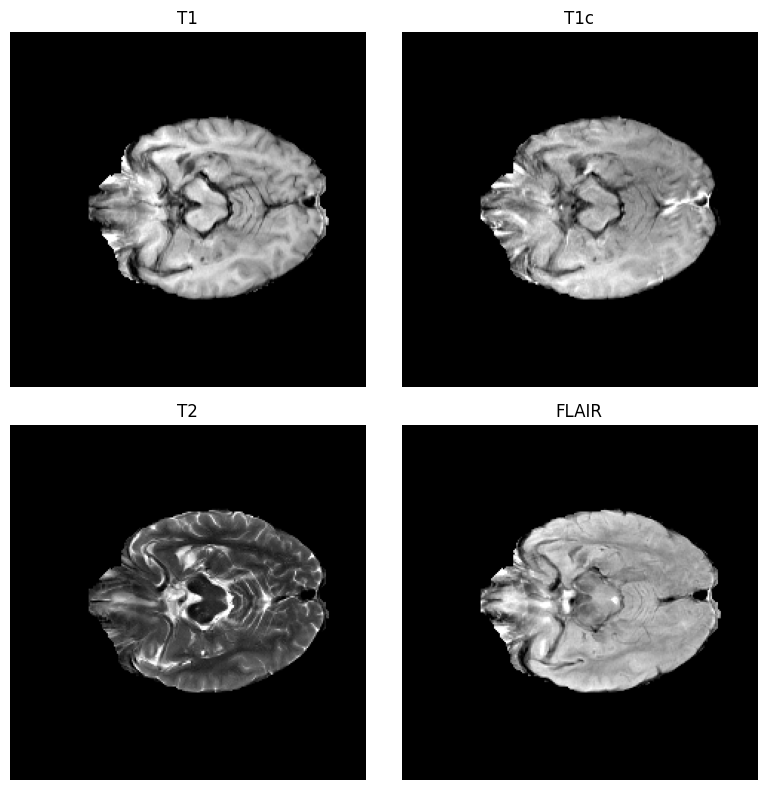

In [25]:
import matplotlib.pyplot as plt
import random

def show_sample_from_sequence(seq, sample_index=None):
    # pick a random sample from the generator if index not given
    if sample_index is None:
        batch_idx = random.randint(0, len(seq) - 1)
        x_batch, y_batch = seq[batch_idx]
        i = random.randint(0, x_batch.shape[0] - 1)
    else:
        # map a global index to batch + offset
        batch_idx = sample_index // seq.batch_size
        i = sample_index % seq.batch_size
        x_batch, y_batch = seq[batch_idx]

    x = x_batch[i]      # (240,240,4)
    y = y_batch[i]      # (3,) one-hot

    print("Sample shape:", x.shape, "Label (one-hot):", y)

    # plot each modality separately
    titles = ["T1", "T1c", "T2", "FLAIR"]
    plt.figure(figsize=(8, 8))
    for c in range(4):
        plt.subplot(2, 2, c+1)
        plt.imshow(x[:, :, c], cmap="gray")
        plt.title(titles[c])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Show one random training slice (all 4 channels)
show_sample_from_sequence(train_gen)


In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

label_to_name = {lbl: CLASS_ROOTS[lbl][0] for lbl in CLASS_ROOTS.keys()}  # 0->GLI,1->METS,2->OTHER

def build_case_modality_df(case_dict, include_planned=False):
    rows = []
    for case_key, entry in case_dict.items():
        lbl = entry["class_label"]
        cname = entry["class_name"]
        for mod in MODALITIES:
            raw_n = len(entry["modalities"].get(mod, []))
            planned_n = None
            if include_planned:
                planned_n = len(entry["slice_plan"][mod])
            rows.append({
                "case_key": case_key,
                "class_label": lbl,
                "class_name": cname,
                "modality": mod,
                "raw_slices": raw_n,
                "planned_slices": planned_n,
            })
    return pd.DataFrame(rows)

df_raw = build_case_modality_df(case_index, include_planned=False)                 # before QC
df_clean = build_case_modality_df(clean_case_index, include_planned=True)         # after QC (planned exists)

# Dropped cases per class
dropped_by_class = []
for cid in dropped_cases:
    entry = case_index[cid]
    dropped_by_class.append(entry["class_name"])
dropped_counts = pd.Series(dropped_by_class).value_counts().reindex(["GLI","METS","OTHER"], fill_value=0)
dropped_counts

GLI       8
METS     33
OTHER    26
Name: count, dtype: int64

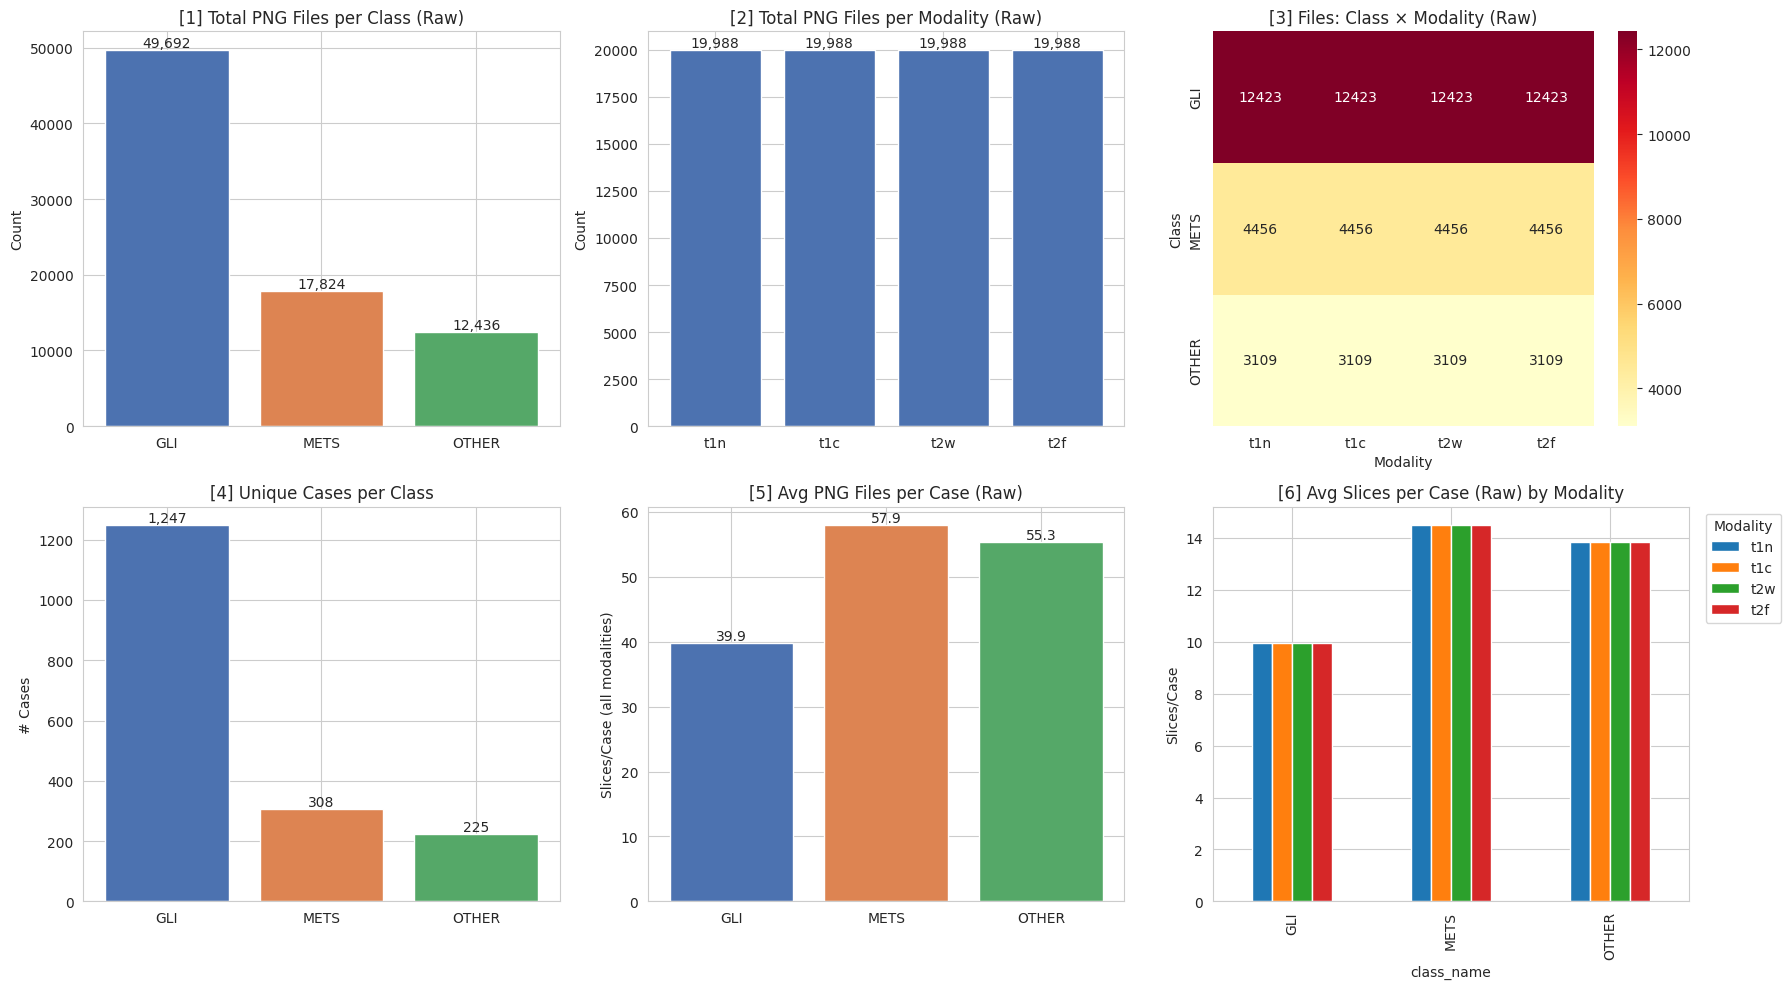

In [18]:
def plot_dataset_dashboard(df_raw):
    # Total PNGs per class (sum over modalities)
    total_png_by_class = df_raw.groupby("class_name")["raw_slices"].sum().reindex(["GLI","METS","OTHER"])

    # Total PNGs per modality (sum over classes)
    total_png_by_mod = df_raw.groupby("modality")["raw_slices"].sum().reindex(MODALITIES)

    # Heatmap class x modality
    heat = (df_raw.pivot_table(index="class_name", columns="modality", values="raw_slices", aggfunc="sum")
                 .reindex(index=["GLI","METS","OTHER"], columns=MODALITIES))

    # Unique cases per class
    cases_per_class = df_raw[["case_key","class_name"]].drop_duplicates().groupby("class_name").size().reindex(["GLI","METS","OTHER"])

    # Avg PNG per case (total over modalities / cases)
    avg_png_per_case = (total_png_by_class / cases_per_class).round(2)

    # Avg slices per case by modality
    avg_slices_case_mod = (df_raw.groupby(["class_name","modality"])["raw_slices"].mean()
                           .unstack("modality").reindex(index=["GLI","METS","OTHER"], columns=MODALITIES).round(2))

    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3)

    # [1] Total PNG files per dataset/class
    ax1 = fig.add_subplot(gs[0,0])
    bars = ax1.bar(total_png_by_class.index, total_png_by_class.values, color=["#4C72B0","#DD8452","#55A868"])
    ax1.set_title("[1] Total PNG Files per Class (Raw)")
    ax1.set_ylabel("Count")
    for b in bars:
        ax1.text(b.get_x()+b.get_width()/2, b.get_height(), f"{int(b.get_height()):,}", ha="center", va="bottom")

    # [2] Total PNG files per modality
    ax2 = fig.add_subplot(gs[0,1])
    bars = ax2.bar(total_png_by_mod.index, total_png_by_mod.values, color="#4C72B0")
    ax2.set_title("[2] Total PNG Files per Modality (Raw)")
    ax2.set_ylabel("Count")
    for b in bars:
        ax2.text(b.get_x()+b.get_width()/2, b.get_height(), f"{int(b.get_height()):,}", ha="center", va="bottom")

    # [3] Heatmap class x modality
    ax3 = fig.add_subplot(gs[0,2])
    sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlOrRd", cbar=True, ax=ax3)
    ax3.set_title("[3] Files: Class × Modality (Raw)")
    ax3.set_xlabel("Modality")
    ax3.set_ylabel("Class")

    # [4] Unique cases per class
    ax4 = fig.add_subplot(gs[1,0])
    bars = ax4.bar(cases_per_class.index, cases_per_class.values, color=["#4C72B0","#DD8452","#55A868"])
    ax4.set_title("[4] Unique Cases per Class")
    ax4.set_ylabel("# Cases")
    for b in bars:
        ax4.text(b.get_x()+b.get_width()/2, b.get_height(), f"{int(b.get_height()):,}", ha="center", va="bottom")

    # [5] Avg PNG files per case
    ax5 = fig.add_subplot(gs[1,1])
    bars = ax5.bar(avg_png_per_case.index, avg_png_per_case.values, color=["#4C72B0","#DD8452","#55A868"])
    ax5.set_title("[5] Avg PNG Files per Case (Raw)")
    ax5.set_ylabel("Slices/Case (all modalities)")
    for b in bars:
        ax5.text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():.1f}", ha="center", va="bottom")

    # [6] Avg slices per case by modality (grouped bars)
    ax6 = fig.add_subplot(gs[1,2])
    avg_slices_case_mod.plot(kind="bar", ax=ax6)
    ax6.set_title("[6] Avg Slices per Case (Raw) by Modality")
    ax6.set_ylabel("Slices/Case")
    ax6.legend(title="Modality", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

plot_dataset_dashboard(df_raw)

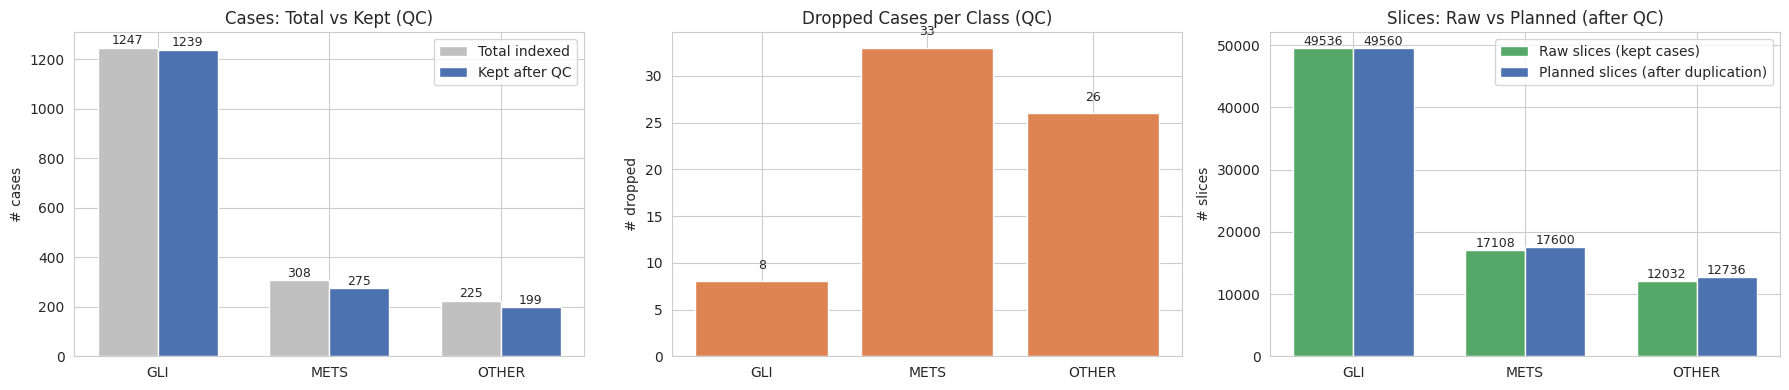

In [32]:
def plot_qc_and_planned(df_raw, df_clean, dropped_counts):
    import numpy as np
    import matplotlib.pyplot as plt

    def annotate_bars(ax, bars, offset=0):
        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width() / 2,
                h + offset,
                f"{int(h)}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    # kept cases per class
    kept_cases = (
        df_clean[["case_key","class_name"]]
        .drop_duplicates()
        .groupby("class_name")
        .size()
        .reindex(["GLI","METS","OTHER"], fill_value=0)
    )

    total_cases = (
        df_raw[["case_key","class_name"]]
        .drop_duplicates()
        .groupby("class_name")
        .size()
        .reindex(["GLI","METS","OTHER"], fill_value=0)
    )

    # planned slice totals per class
    planned_total_by_class = (
        df_clean.groupby("class_name")["planned_slices"]
        .sum()
        .reindex(["GLI","METS","OTHER"])
    )

    # raw slice totals (kept cases)
    raw_total_kept_by_class = (
        df_clean.groupby("class_name")["raw_slices"]
        .sum()
        .reindex(["GLI","METS","OTHER"])
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    names = ["GLI","METS","OTHER"]
    x = np.arange(3)

    # --- Plot 1: Total vs Kept cases (SIDE-BY-SIDE) ---
    ax = axes[0]
    w = 0.35
    
    bars_total = ax.bar(
        x - w/2,
        total_cases.values,
        width=w,
        label="Total indexed",
        color="#C0C0C0"
    )
    
    bars_kept = ax.bar(
        x + w/2,
        kept_cases.values,
        width=w,
        label="Kept after QC",
        color="#4C72B0"
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title("Cases: Total vs Kept (QC)")
    ax.set_ylabel("# cases")
    ax.legend()
    
    annotate_bars(ax, bars_total, offset=2)
    annotate_bars(ax, bars_kept, offset=2)


    # --- Plot 2: Dropped cases ---
    ax = axes[1]
    bars_dropped = ax.bar(dropped_counts.index, dropped_counts.values, color="#DD8452")
    ax.set_title("Dropped Cases per Class (QC)")
    ax.set_ylabel("# dropped")

    annotate_bars(ax, bars_dropped, offset=1)

    # --- Plot 3: Raw vs Planned slices ---
    ax = axes[2]
    w = 0.35
    bars_raw = ax.bar(
        x - w/2,
        raw_total_kept_by_class.values,
        width=w,
        label="Raw slices (kept cases)",
        color="#55A868"
    )
    bars_planned = ax.bar(
        x + w/2,
        planned_total_by_class.values,
        width=w,
        label="Planned slices (after duplication)",
        color="#4C72B0"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title("Slices: Raw vs Planned (after QC)")
    ax.set_ylabel("# slices")
    ax.legend()

    annotate_bars(ax, bars_raw, offset=10)
    annotate_bars(ax, bars_planned, offset=10)

    plt.tight_layout()
    plt.show()
plot_qc_and_planned(df_raw, df_clean, dropped_counts)

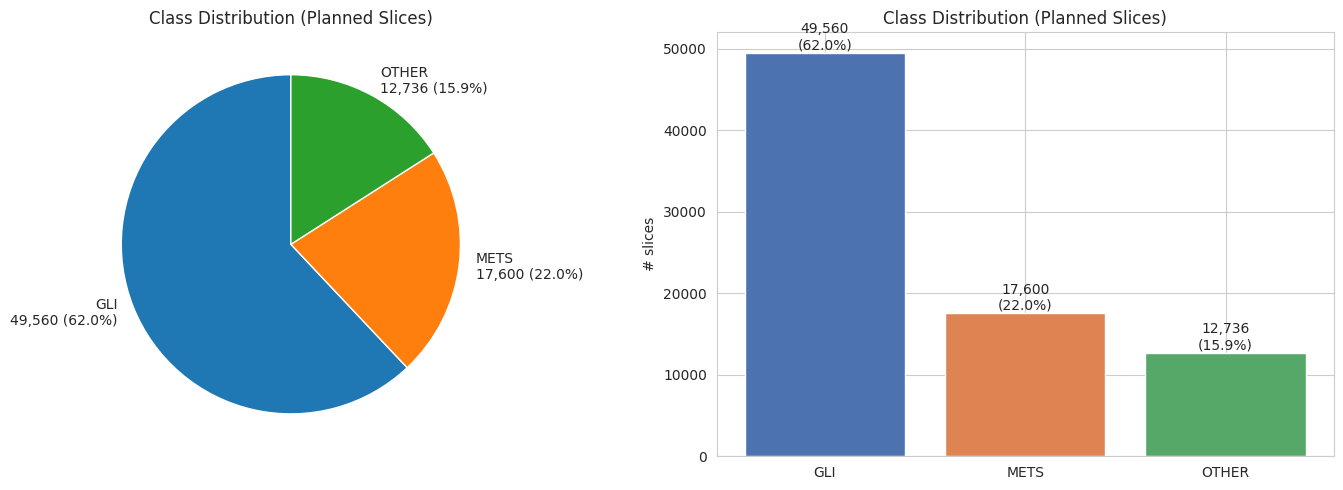

In [20]:
def plot_class_distribution_planned(df_clean):
    planned_by_class = df_clean.groupby("class_name")["planned_slices"].sum().reindex(["GLI","METS","OTHER"])
    total = planned_by_class.sum()
    pct = (planned_by_class / total * 100).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Pie
    axes[0].pie(planned_by_class.values,
                labels=[f"{k}\n{v:,} ({pct[k]}%)" for k,v in planned_by_class.items()],
                startangle=90)
    axes[0].set_title("Class Distribution (Planned Slices)")

    # Bar
    bars = axes[1].bar(planned_by_class.index, planned_by_class.values, color=["#4C72B0","#DD8452","#55A868"])
    axes[1].set_title("Class Distribution (Planned Slices)")
    axes[1].set_ylabel("# slices")
    for b, name in zip(bars, planned_by_class.index):
        axes[1].text(b.get_x()+b.get_width()/2, b.get_height(),
                     f"{int(b.get_height()):,}\n({pct[name]}%)",
                     ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

plot_class_distribution_planned(df_clean)

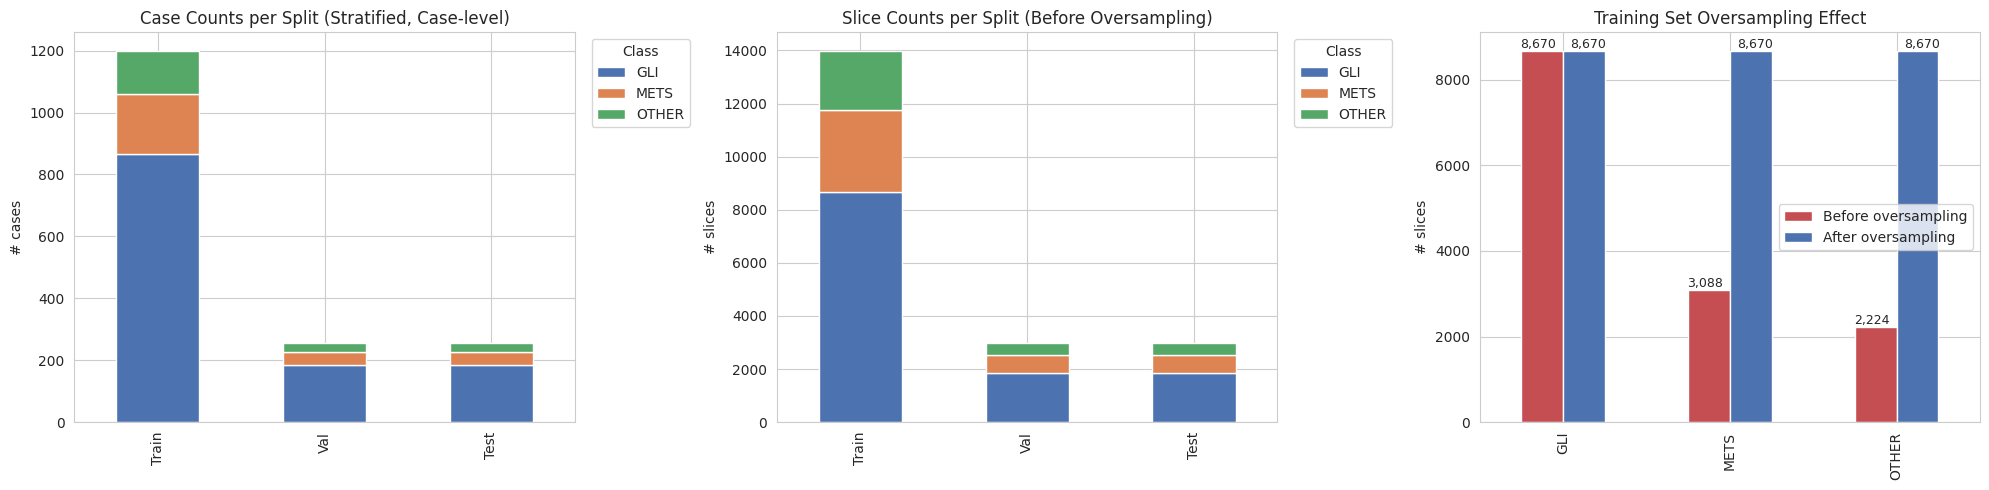

In [21]:
from collections import Counter

def plot_splits_and_oversampling(clean_case_index, train_cases, val_cases, test_cases,
                                 train_slices, val_slices, test_slices, balanced_train_slices):
    def cases_per_class(case_set):
        c = Counter()
        for cid in case_set:
            c[clean_case_index[cid]["class_name"]] += 1
        return pd.Series(c).reindex(["GLI","METS","OTHER"], fill_value=0)

    def slices_per_class(slice_list):
        c = Counter()
        for _,_,lbl in slice_list:
            c[label_to_name[lbl]] += 1
        return pd.Series(c).reindex(["GLI","METS","OTHER"], fill_value=0)

    # Cases
    cases_df = pd.DataFrame({
        "Train": cases_per_class(train_cases),
        "Val":   cases_per_class(val_cases),
        "Test":  cases_per_class(test_cases),
    })

    # Slices (before OS)
    slices_df = pd.DataFrame({
        "Train": slices_per_class(train_slices),
        "Val":   slices_per_class(val_slices),
        "Test":  slices_per_class(test_slices),
    })

    # Oversampling: before vs after in train
    train_before = slices_per_class(train_slices)
    train_after  = slices_per_class(balanced_train_slices)
    os_df = pd.DataFrame({"Before oversampling": train_before, "After oversampling": train_after})

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Cases per split (stacked)
    cases_df.T.plot(kind="bar", stacked=True, ax=axes[0], color=["#4C72B0","#DD8452","#55A868"])
    axes[0].set_title("Case Counts per Split (Stratified, Case-level)")
    axes[0].set_ylabel("# cases")
    axes[0].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

    # Slices per split (stacked, before OS)
    slices_df.T.plot(kind="bar", stacked=True, ax=axes[1], color=["#4C72B0","#DD8452","#55A868"])
    axes[1].set_title("Slice Counts per Split (Before Oversampling)")
    axes[1].set_ylabel("# slices")
    axes[1].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

    # Oversampling effect
    os_df.plot(kind="bar", ax=axes[2], color=["#C44E52","#4C72B0"])
    axes[2].set_title("Training Set Oversampling Effect")
    axes[2].set_ylabel("# slices")
    for i, cls in enumerate(os_df.index):
        axes[2].text(i-0.15, os_df.iloc[i,0], f"{int(os_df.iloc[i,0]):,}", ha="center", va="bottom", fontsize=9)
        axes[2].text(i+0.15, os_df.iloc[i,1], f"{int(os_df.iloc[i,1]):,}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

plot_splits_and_oversampling(clean_case_index, train_cases, val_cases, test_cases,
                            train_slices, val_slices, test_slices, balanced_train_slices)

Class: GLI | one-hot: [1. 0. 0.]


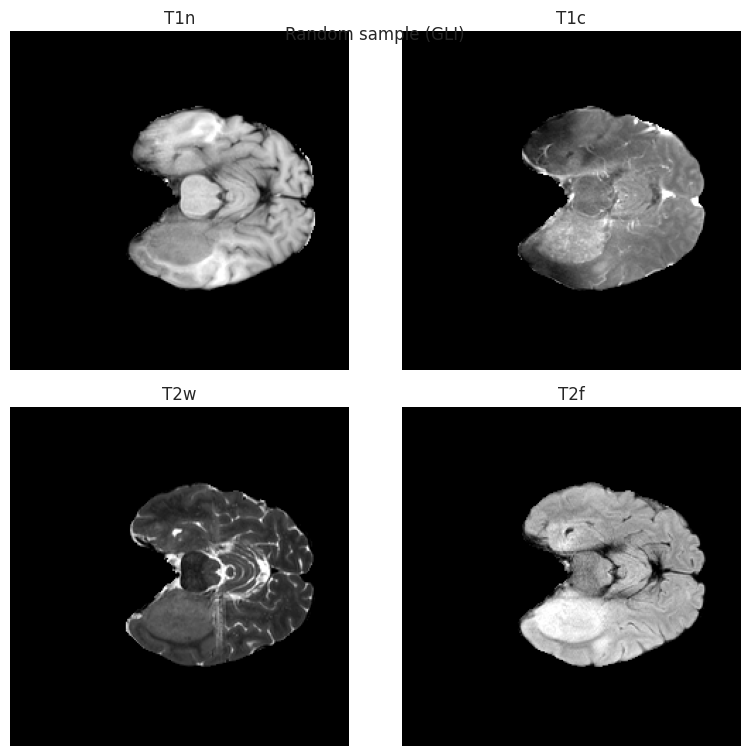

Class: METS | one-hot: [0. 1. 0.]


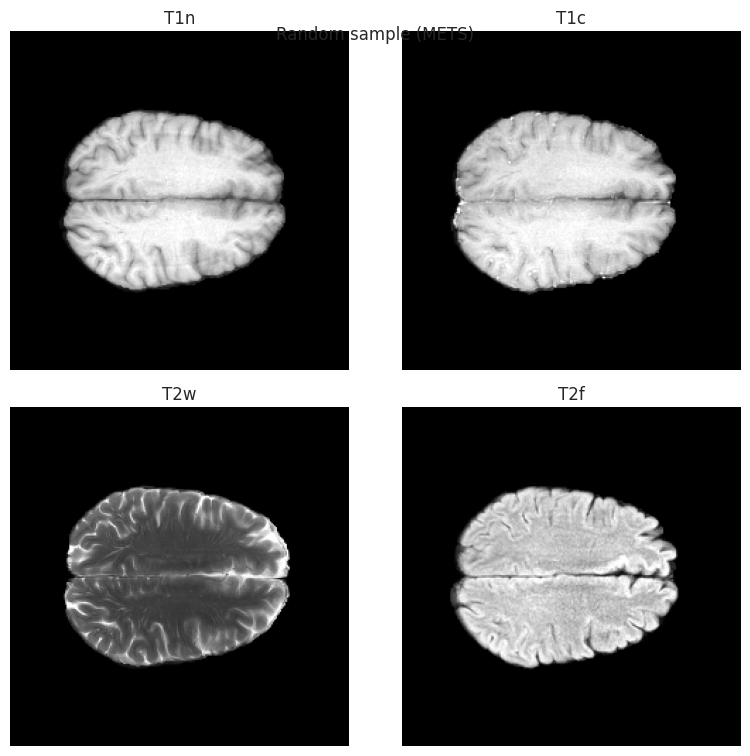

Class: OTHER | one-hot: [0. 0. 1.]


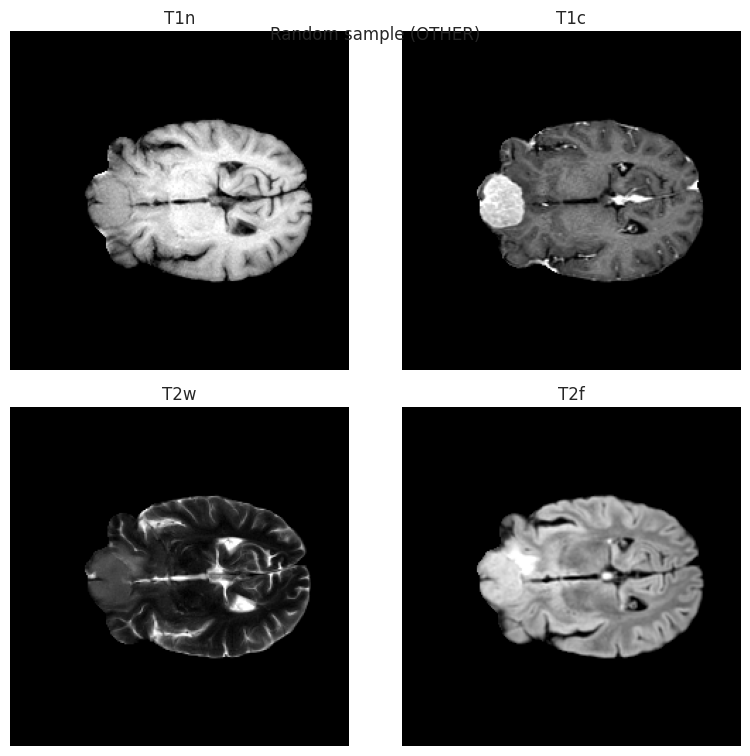

In [22]:
import random
import matplotlib.pyplot as plt

def show_one_per_class(seq, class_names=("GLI","METS","OTHER"), tries=500):
    # brute-force search random batches until we find each class
    found = {c: None for c in class_names}

    for _ in range(tries):
        b = random.randint(0, len(seq)-1)
        x_batch, y_batch = seq[b]
        y_lbl = np.argmax(y_batch, axis=1)
        for i in range(x_batch.shape[0]):
            cname = label_to_name[int(y_lbl[i])]
            if cname in found and found[cname] is None:
                found[cname] = (x_batch[i], y_batch[i])
        if all(found[c] is not None for c in class_names):
            break

    titles = ["T1n", "T1c", "T2w", "T2f"]
    for cname in class_names:
        if found[cname] is None:
            print(f"Could not find class {cname} in {tries} tries.")
            continue
        x, y = found[cname]
        print(f"Class: {cname} | one-hot: {y}")

        plt.figure(figsize=(8,8))
        for c in range(4):
            plt.subplot(2,2,c+1)
            plt.imshow(x[:,:,c], cmap="gray")
            plt.title(titles[c])
            plt.axis("off")
        plt.suptitle(f"Random sample ({cname})", y=0.92)
        plt.tight_layout()
        plt.show()

show_one_per_class(train_gen)

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

CLASS_NAMES = ["GLI", "METS", "OTHER"]  # label 2 is MEN mapped to OTHER

def count_cases_per_class(case_set, case_index):
    c = Counter()
    for cid in case_set:
        c[case_index[cid]["class_name"]] += 1
    return [c.get(k, 0) for k in CLASS_NAMES]

def count_slices_per_class(samples):
    # samples = list of (case_key, local_idx, label)
    c = Counter()
    for _, _, lbl in samples:
        c[CLASS_NAMES[lbl]] += 1
    return [c.get(k, 0) for k in CLASS_NAMES]

def add_bar_labels(ax, bars, fmt="{:,}", y_offset=0.01):
    ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + ymax*y_offset, fmt.format(int(h)),
                ha="center", va="bottom", fontsize=10, fontweight="bold")

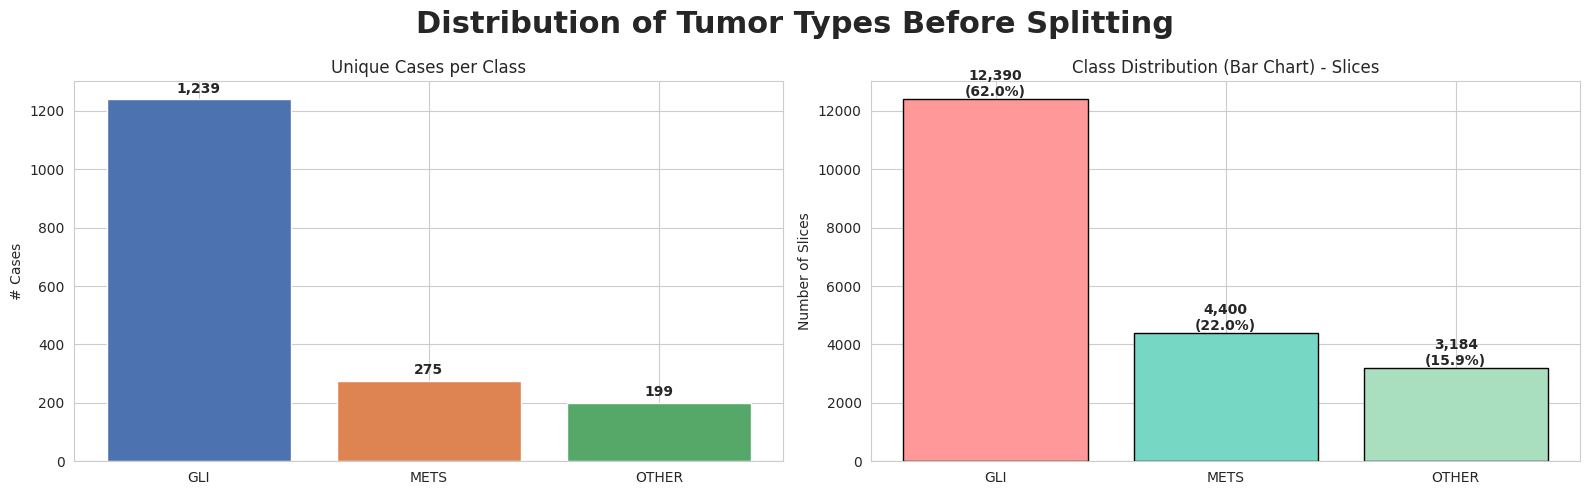

In [34]:
def plot_before_splitting(clean_case_index, slice_samples):
    # unique cases per class
    all_cases = list(clean_case_index.keys())
    case_counts = Counter([clean_case_index[c]["class_name"] for c in all_cases])
    case_vals = [case_counts.get(k, 0) for k in CLASS_NAMES]

    # slices per class (planned)
    slice_vals = count_slices_per_class(slice_samples)
    total_slices = sum(slice_vals)
    pct = [v/total_slices*100 for v in slice_vals]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Distribution of Tumor Types Before Splitting", fontsize=22, fontweight="bold")

    # Left: cases
    ax = axes[0]
    bars = ax.bar(CLASS_NAMES, case_vals, color=["#4C72B0", "#DD8452", "#55A868"])
    ax.set_title("Unique Cases per Class")
    ax.set_ylabel("# Cases")
    add_bar_labels(ax, bars)

    # Right: slices
    ax = axes[1]
    bars = ax.bar(CLASS_NAMES, slice_vals, color=["#FF9999", "#76D7C4", "#A9DFBF"], edgecolor="black")
    ax.set_title("Class Distribution (Bar Chart) - Slices")
    ax.set_ylabel("Number of Slices")
    for b, p in zip(bars, pct):
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, h, f"{int(h):,}\n({p:.1f}%)",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

    plt.tight_layout()
    plt.show()

plot_before_splitting(clean_case_index, slice_samples)

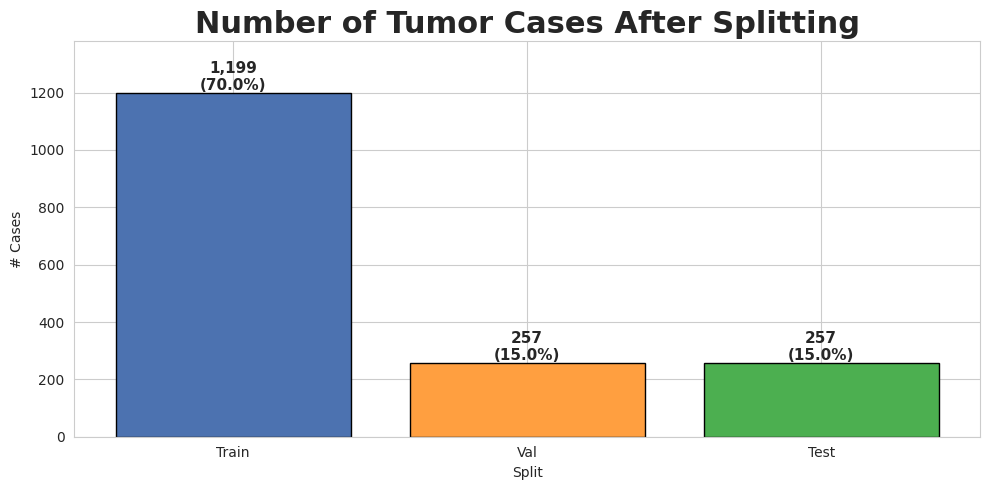

In [35]:
def plot_cases_after_splitting(train_cases, val_cases, test_cases):
    split_names = ["Train", "Val", "Test"]
    split_counts = [len(train_cases), len(val_cases), len(test_cases)]
    total = sum(split_counts)
    split_pct = [c/total*100 for c in split_counts]

    plt.figure(figsize=(10, 5))
    plt.title("Number of Tumor Cases After Splitting", fontsize=22, fontweight="bold")
    bars = plt.bar(split_names, split_counts, color=["#4C72B0", "#FF9F40", "#4CAF50"], edgecolor="black")
    plt.ylabel("# Cases")
    plt.xlabel("Split")

    ymax = max(split_counts) if max(split_counts) > 0 else 1
    plt.ylim(0, ymax * 1.15)

    for b, p in zip(bars, split_pct):
        h = b.get_height()
        plt.text(b.get_x()+b.get_width()/2, h, f"{int(h):,}\n({p:.1f}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

    plt.tight_layout()
    plt.show()

plot_cases_after_splitting(train_cases, val_cases, test_cases)

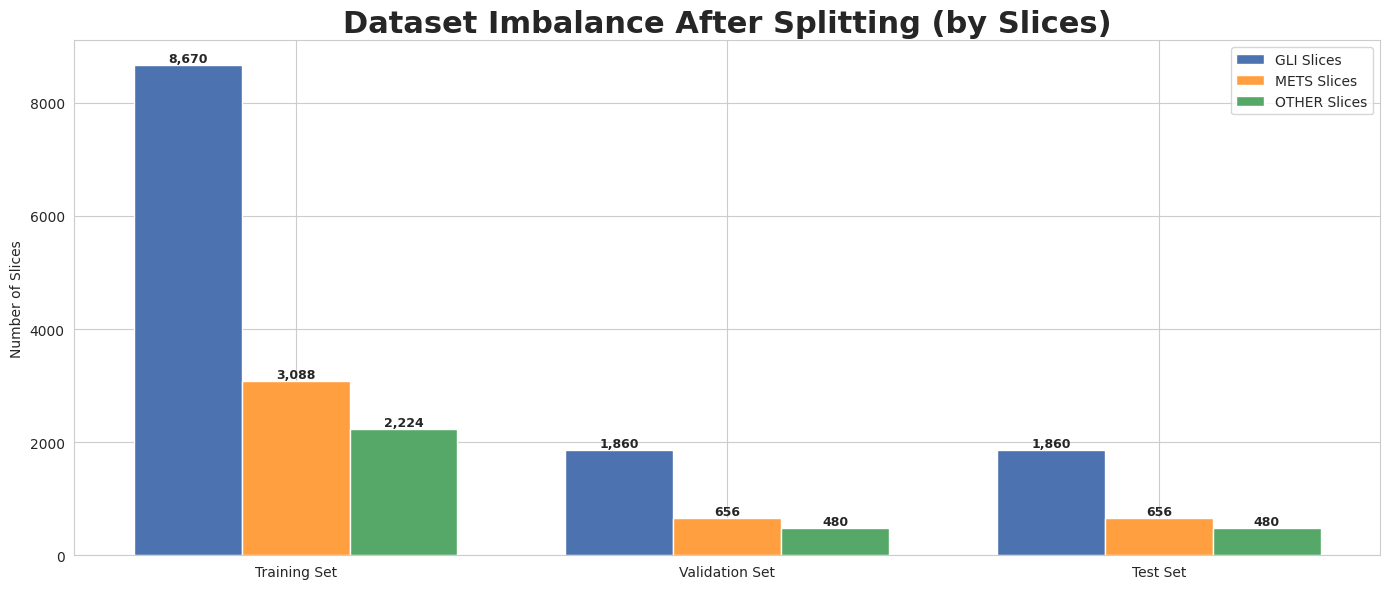

In [36]:
def plot_slice_imbalance_after_splitting(train_slices, val_slices, test_slices):
    splits = ["Training Set", "Validation Set", "Test Set"]
    data = np.array([
        count_slices_per_class(train_slices),
        count_slices_per_class(val_slices),
        count_slices_per_class(test_slices),
    ])  # shape: (3 splits, 3 classes)

    x = np.arange(len(splits))
    w = 0.25

    plt.figure(figsize=(14, 6))
    plt.title("Dataset Imbalance After Splitting (by Slices)", fontsize=22, fontweight="bold")
    plt.ylabel("Number of Slices")

    colors = ["#4C72B0", "#FF9F40", "#55A868"]
    for i, cls in enumerate(CLASS_NAMES):
        bars = plt.bar(x + (i-1)*w, data[:, i], width=w, label=f"{cls} Slices", color=colors[i])
        for b in bars:
            h = b.get_height()
            plt.text(b.get_x()+b.get_width()/2, h, f"{int(h):,}",
                     ha="center", va="bottom", fontsize=9, fontweight="bold")

    plt.xticks(x, splits)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_slice_imbalance_after_splitting(train_slices, val_slices, test_slices)

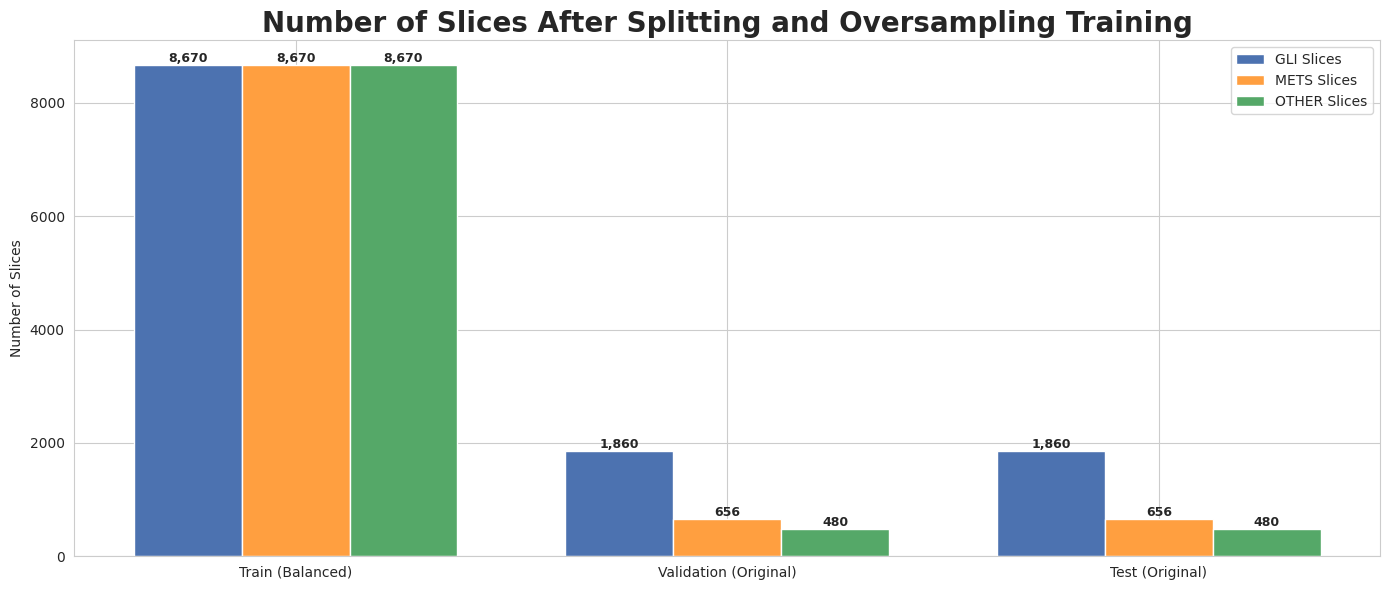

In [37]:
def plot_slices_after_oversampling(balanced_train_slices, val_slices, test_slices):
    splits = ["Train (Balanced)", "Validation (Original)", "Test (Original)"]
    data = np.array([
        count_slices_per_class(balanced_train_slices),
        count_slices_per_class(val_slices),
        count_slices_per_class(test_slices),
    ])

    x = np.arange(len(splits))
    w = 0.25

    plt.figure(figsize=(14, 6))
    plt.title("Number of Slices After Splitting and Oversampling Training", fontsize=20, fontweight="bold")
    plt.ylabel("Number of Slices")

    colors = ["#4C72B0", "#FF9F40", "#55A868"]
    for i, cls in enumerate(CLASS_NAMES):
        bars = plt.bar(x + (i-1)*w, data[:, i], width=w, label=f"{cls} Slices", color=colors[i])
        for b in bars:
            h = b.get_height()
            plt.text(b.get_x()+b.get_width()/2, h, f"{int(h):,}",
                     ha="center", va="bottom", fontsize=9, fontweight="bold")

    plt.xticks(x, splits)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_slices_after_oversampling(balanced_train_slices, val_slices, test_slices)

# EfficientNet Model 

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_HEIGHT = 240
IMG_WIDTH  = 240
NUM_CLASSES = 3

def build_efficientnet_4ch_to_3class(input_shape=(IMG_HEIGHT, IMG_WIDTH, 4),
                                     train_base=False,
                                     dropout1=0.4,
                                     dropout2=0.3):
    """
    EfficientNetB0 adapted for 4-channel MRI input (T1n, T1c, T2w, T2f)
    with 3-class output (GLI, METS, OTHER).
    
    Args:
        input_shape: (240, 240, 4)
        train_base: If False, freeze EfficientNetB0 backbone
        dropout1: First dropout rate
        dropout2: Second dropout rate
    
    Returns:
        Keras Model
    """
    
    inp = layers.Input(shape=input_shape, name="input_4ch")
    
    # 4→3 channel adapter (learned 1×1 convolution)
    x = layers.Conv2D(3, (1, 1), padding="same", name="adapter_4to3")(inp)
    
    # EfficientNetB0 preprocessing expects [0, 255] then scales to [-1, 1]
    x = layers.Lambda(lambda t: t * 255.0, name="to_255")(x)
    x = layers.Lambda(preprocess_input, name="efficient_preprocess")(x)
    
    # Load EfficientNetB0 pretrained on ImageNet
    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )
    base.trainable = train_base  # Frozen for initial training
    
    feat = base(x)
    
    # Classification head
    h = layers.GlobalAveragePooling2D(name="gap")(feat)
    h = layers.Dropout(dropout1, name="drop1")(h)
    h = layers.Dense(256, activation="relu", name="fc1")(h)
    h = layers.Dropout(dropout2, name="drop2")(h)
    out = layers.Dense(NUM_CLASSES, activation="softmax", name="pred")(h)
    
    model = Model(inputs=inp, outputs=out, name="EfficientNetB0_4ch_3class")
    return model

# Build the model (backbone frozen)
model_efficient = build_efficientnet_4ch_to_3class(train_base=False)

print("✅ EfficientNetB0 model created successfully!")

✅ EfficientNetB0 model created successfully!


# compile the Model

In [28]:
multi_auc = tf.keras.metrics.AUC(
    multi_label=True, 
    num_labels=NUM_CLASSES, 
    name="auc"
)

model_efficient.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", multi_auc]
)

print("✅ Model compiled with Adam (lr=1e-4), categorical_crossentropy, and AUC metric")

✅ Model compiled with Adam (lr=1e-4), categorical_crossentropy, and AUC metric


In [29]:
model_efficient.summary()

Model: "EfficientNetB0_4ch_3class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_4ch (InputLayer)          │ (None, 240, 240, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_4to3 (Conv2D)           │ (None, 240, 240, 3)    │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_255 (Lambda)                 │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficient_preprocess (Lambda)   │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,293 (16.70 MB)

 Trainable params: 328,722 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [30]:
# Test forward pass
xb, yb = train_gen[0]
print("Input batch shape:", xb.shape, "| Range:", xb.min(), "-", xb.max())
print("Label batch shape:", yb.shape, "| Classes in batch:", sorted(set(yb.argmax(axis=1))))

pred = model_efficient(xb[:2])
print("Prediction shape:", pred.shape)
print("Prediction row sums (should be ~1.0):", tf.reduce_sum(pred, axis=1).numpy())

Input batch shape: (32, 240, 240, 4) | Range: 0.0 - 1.0
Label batch shape: (32, 3) | Classes in batch: [np.int64(0), np.int64(1), np.int64(2)]


I0000 00:00:1772103662.776116      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


Prediction shape: (2, 3)
Prediction row sums (should be ~1.0): [1. 1.]


# Add the Callbacks

In [31]:
EPOCHS_STAGE0 = 30  # Initial training epochs (you can adjust)

ckpt_path_stage0 = "efficientnet_3class_stage0_best.keras"

callbacks_stage0 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path_stage0,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print("✅ Callbacks configured:")
print("  - EarlyStopping: patience=6 on val_auc")
print("  - ReduceLROnPlateau: factor=0.5, patience=3")
print("  - ModelCheckpoint: saves best val_auc model")

✅ Callbacks configured:
  - EarlyStopping: patience=6 on val_auc
  - ReduceLROnPlateau: factor=0.5, patience=3
  - ModelCheckpoint: saves best val_auc model


In [32]:
print("🚀 Starting Stage 0 training (frozen EfficientNetB0 backbone)...")
print(f"   Training only: adapter (4→3) + classification head (~132K params)")
print(f"   Epochs: {EPOCHS_STAGE0}")
print(f"   Learning rate: 1e-4\n")

history_stage0 = model_efficient.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE0,
    callbacks=callbacks_stage0,
    verbose=1
)

print("\n✅ Stage 0 training complete!")

🚀 Starting Stage 0 training (frozen EfficientNetB0 backbone)...
   Training only: adapter (4→3) + classification head (~132K params)
   Epochs: 30
   Learning rate: 1e-4

Epoch 1/30


I0000 00:00:1772103686.565992     362 service.cc:152] XLA service 0x7fb114002530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772103686.566034     362 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772103705.086111     362 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.5343 - auc: 0.7278 - loss: 0.9312
Epoch 1: val_auc improved from -inf to 0.81524, saving model to efficientnet_3class_stage0_best.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 597s 696ms/step - accuracy: 0.5344 - auc: 0.7279 - loss: 0.9311 - val_accuracy: 0.6061 - val_auc: 0.8152 - val_loss: 0.8412 - learning_rate: 1.0000e-04
Epoch 2/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.6710 - auc: 0.8426 - loss: 0.7401
Epoch 2: val_auc improved from 0.81524 to 0.85014, saving model to efficientnet_3class_stage0_best.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 169s 208ms/step - accuracy: 0.6710 - auc: 0.8427 - loss: 0.7401 - val_accuracy: 0.6779 - val_auc: 0.8501 - val_loss: 0.7003 - learning_rate: 1.0000e-04
Epoch 3/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.6908 - auc: 0.8633 - loss: 0.6910
Epoch 3: val_auc improved from 0.85014 to 0.86771, saving model to efficientnet_3class_stage0_best.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 17

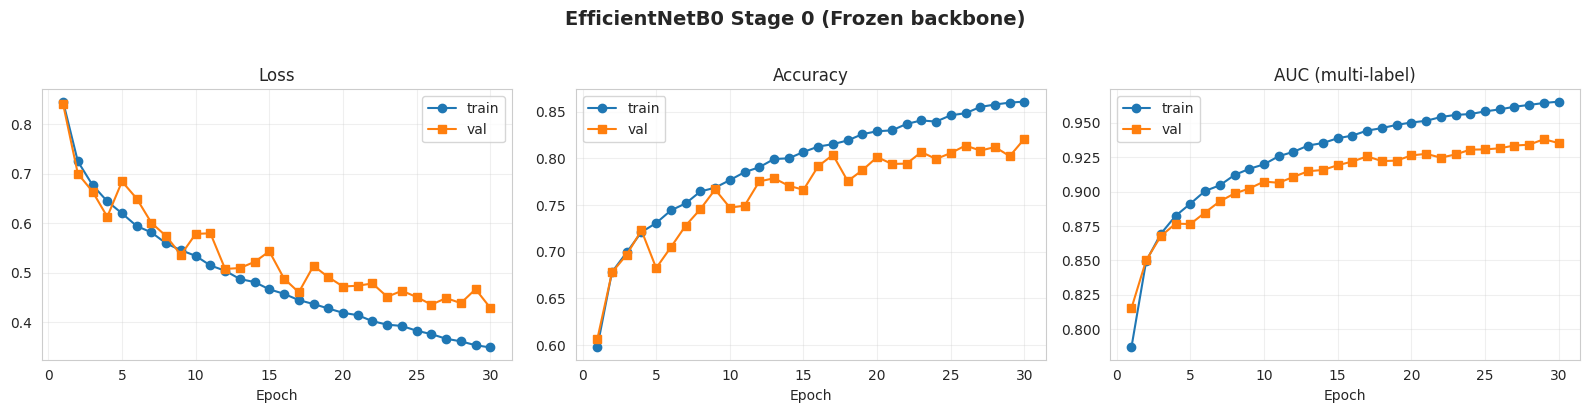

In [33]:
import matplotlib.pyplot as plt

def plot_history(hist, title="Training Curves"):
    h = hist.history
    epochs = range(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Loss
    axes[0].plot(epochs, h["loss"], label="train", marker='o')
    axes[0].plot(epochs, h["val_loss"], label="val", marker='s')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, h["accuracy"], label="train", marker='o')
    axes[1].plot(epochs, h["val_accuracy"], label="val", marker='s')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # AUC
    axes[2].plot(epochs, h["auc"], label="train", marker='o')
    axes[2].plot(epochs, h["val_auc"], label="val", marker='s')
    axes[2].set_title("AUC (multi-label)")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_history(history_stage0, "EfficientNetB0 Stage 0 (Frozen backbone)")

📊 EVALUATION: STAGE 0 (Frozen EfficientNetB0 Backbone)
94/94 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step

🔹 SLICE-LEVEL RESULTS (Stage 0)
Accuracy: 80.74%

              precision    recall  f1-score   support

         GLI     0.9281    0.7844    0.8502      1860
        METS     0.7811    0.8704    0.8234       656
       OTHER     0.5613    0.8104    0.6633       480

    accuracy                         0.8074      2996
   macro avg     0.7569    0.8218    0.7789      2996
weighted avg     0.8372    0.8074    0.8144      2996



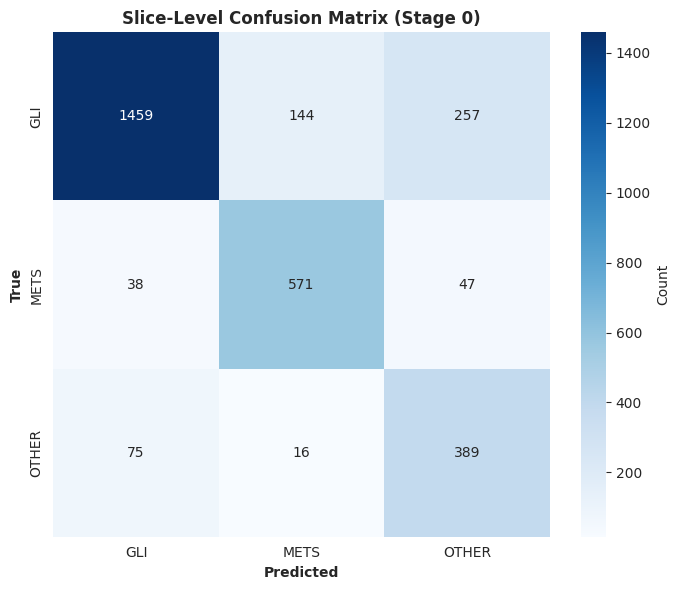

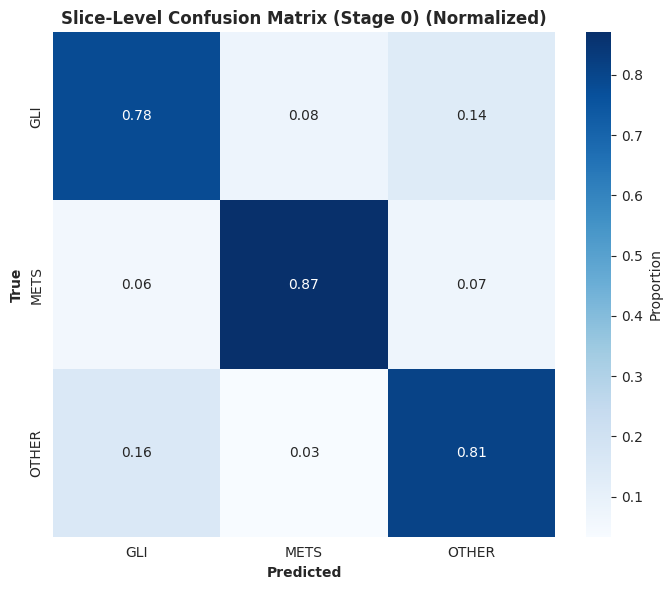


🔹 CASE-LEVEL RESULTS (Majority Voting - Stage 0)
Accuracy: 87.16%

              precision    recall  f1-score   support

         GLI     0.9641    0.8656    0.9122       186
        METS     0.7551    0.9024    0.8222        41
       OTHER     0.6341    0.8667    0.7324        30

    accuracy                         0.8716       257
   macro avg     0.7844    0.8782    0.8223       257
weighted avg     0.8922    0.8716    0.8768       257



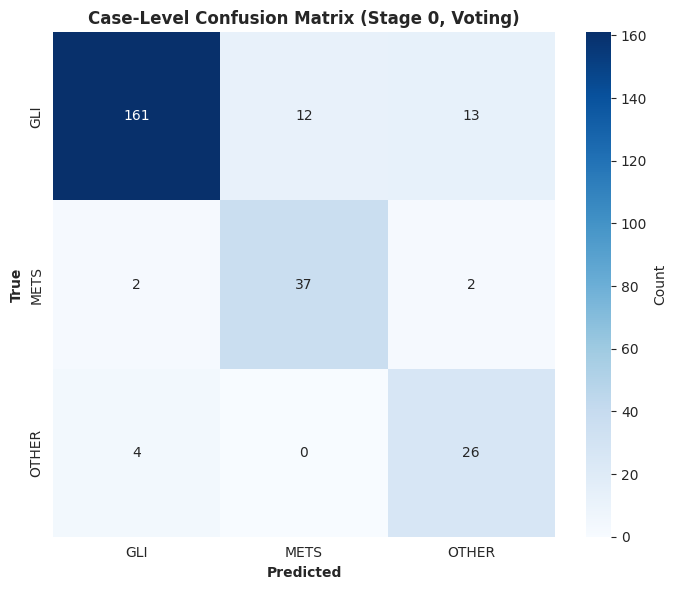

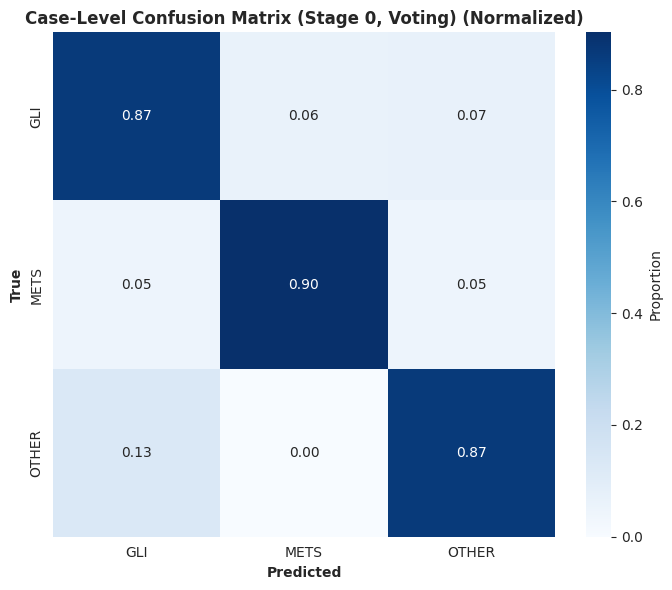

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

CLASS_NAMES = ["GLI", "METS", "OTHER"]

def plot_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, 
        fmt=".2f" if normalize else "d",
        cmap="Blues", 
        xticklabels=CLASS_NAMES, 
        yticklabels=CLASS_NAMES,
        cbar_kws={'label': 'Count' if not normalize else 'Proportion'}
    )
    plt.title(title + (" (Normalized)" if normalize else ""), fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")
    plt.tight_layout()
    plt.show()

def predict_with_metadata(model, gen):
    y_prob = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    case_keys = [ck for (ck, local_idx, lbl) in gen.samples]
    y_true = np.array([lbl for (ck, local_idx, lbl) in gen.samples], dtype=np.int32)
    return y_true, y_pred, y_prob, case_keys

def majority_vote(arr, n_classes=3):
    counts = np.bincount(arr, minlength=n_classes)
    top = counts.max()
    tied = np.where(counts == top)[0]
    return int(tied[0])

def case_level_vote(y_pred_slice, case_keys, clean_case_index):
    df = pd.DataFrame({"case_key": case_keys, "pred": y_pred_slice})
    y_pred_case = df.groupby("case_key")["pred"].apply(
        lambda s: majority_vote(s.values, n_classes=3)
    )
    y_true_case = y_pred_case.index.to_series().apply(
        lambda ck: clean_case_index[ck]["class_label"]
    )
    return y_true_case.values.astype(int), y_pred_case.values.astype(int)

# ----- Evaluate on test set -----
print("=" * 70)
print("📊 EVALUATION: STAGE 0 (Frozen EfficientNetB0 Backbone)")
print("=" * 70)

eval_gen = test_gen  # must have shuffle=False

# Slice-level
y_true_slice, y_pred_slice, _, case_keys = predict_with_metadata(model_efficient, eval_gen)

print("\n" + "="*70)
print("🔹 SLICE-LEVEL RESULTS (Stage 0)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%\n")
print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix (Stage 0)", normalize=False)
plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix (Stage 0)", normalize=True)

# Case-level (majority voting)
y_true_case, y_pred_case = case_level_vote(y_pred_slice, case_keys, clean_case_index)

print("\n" + "="*70)
print("🔹 CASE-LEVEL RESULTS (Majority Voting - Stage 0)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_case, y_pred_case)*100:.2f}%\n")
print(classification_report(y_true_case, y_pred_case, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_case, y_pred_case, "Case-Level Confusion Matrix (Stage 0, Voting)", normalize=False)
plot_cm(y_true_case, y_pred_case, "Case-Level Confusion Matrix (Stage 0, Voting)", normalize=True)

# Fine tuning

In [35]:
import tensorflow as tf
import keras

# Enable unsafe deserialization
keras.config.enable_unsafe_deserialization()

NUM_CLASSES = 3
multi_auc = tf.keras.metrics.AUC(multi_label=True, num_labels=NUM_CLASSES, name="auc")

# Load the best Stage 0 model
model_efficient = keras.models.load_model(
    "/kaggle/working/efficientnet_3class_stage0_best.keras",
    custom_objects={
        "auc": multi_auc,
        "preprocess_input": preprocess_input
    }
)

In [36]:
import tensorflow as tf
from tensorflow.keras import layers

print("✅ EfficientNetB0 Stage 0 model loaded successfully!")

# ------------------------------------------------------------
# 1) Extract the EfficientNetB0 base model from your full model
# ------------------------------------------------------------
efficient_base = None
for layer in model_efficient.layers:
    if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
        efficient_base = layer
        break

# Fallback: sometimes Keras names it just "efficientnetb0"
if efficient_base is None:
    for layer in model_efficient.layers:
        if isinstance(layer, tf.keras.Model) and "efficient" in layer.name.lower():
            efficient_base = layer
            break

if efficient_base is None:
    raise ValueError("❌ Could not find EfficientNetB0 base model inside model_efficient")

print(f"\n✅ Found EfficientNet base: {efficient_base.name}")
print(f"   Total layers in base: {len(efficient_base.layers)}")


# ------------------------------------------------------------
# 2) Freeze all layers first
# ------------------------------------------------------------
for layer in efficient_base.layers:
    layer.trainable = False


# ------------------------------------------------------------
# 3) Unfreeze LAST 30 layers (keep BatchNorm frozen)
# ------------------------------------------------------------
N_UNFREEZE = 30

for layer in efficient_base.layers[-N_UNFREEZE:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

# Verify what got unfrozen
unfrozen = [l.name for l in efficient_base.layers if l.trainable]
print(f"\n✅ Unfrozen {len(unfrozen)} layers in Stage 1 (last {N_UNFREEZE} layers, BN frozen)")
print(f"   Examples: {unfrozen[:5]} ... {unfrozen[-5:]}")


# ------------------------------------------------------------
# 4) Count trainable / non-trainable params
# ------------------------------------------------------------
trainable_count = sum([tf.size(w).numpy() for w in model_efficient.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in model_efficient.non_trainable_weights])

print(f"\n📊 Trainable params:     {trainable_count:,}")
print(f"📊 Non-trainable params: {non_trainable_count:,}")


# ------------------------------------------------------------
# 5) Recompile (fine-tuning LR)
# ------------------------------------------------------------
multi_auc = tf.keras.metrics.AUC(multi_label=True, num_labels=NUM_CLASSES, name="auc")

model_efficient.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 10x lower than Stage 0
    loss="categorical_crossentropy",
    metrics=["accuracy", multi_auc]
)

print("✅ Model recompiled with LR=1e-5 for fine-tuning Stage 1")


# ------------------------------------------------------------
# 6) Callbacks + fit
# ------------------------------------------------------------
EPOCHS_FT_STAGE1 = 20
ckpt_path_ft1 = "efficientnet_3class_finetune_stage1.keras"

callbacks_ft1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path_ft1,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print(f"🚀 Starting Fine-tuning Stage 1 (EfficientNetB0 last {N_UNFREEZE} layers)...")
print(f"   Epochs: {EPOCHS_FT_STAGE1}")
print(f"   Learning rate: 1e-5\n")

history_ft_stage1 = model_efficient.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT_STAGE1,
    callbacks=callbacks_ft1,
    verbose=1
)

print("\n✅ Fine-tuning Stage 1 complete!")

✅ EfficientNetB0 Stage 0 model loaded successfully!

✅ Found EfficientNet base: efficientnetb0
   Total layers in base: 238

✅ Unfrozen 23 layers in Stage 1 (last 30 layers, BN frozen)
   Examples: ['block6d_expand_activation', 'block6d_dwconv', 'block6d_activation', 'block6d_se_squeeze', 'block6d_se_reshape'] ... ['block7a_se_expand', 'block7a_se_excite', 'block7a_project_conv', 'top_conv', 'top_activation']

📊 Trainable params:     1,812,082
📊 Non-trainable params: 2,566,211
✅ Model recompiled with LR=1e-5 for fine-tuning Stage 1
🚀 Starting Fine-tuning Stage 1 (EfficientNetB0 last 30 layers)...
   Epochs: 20
   Learning rate: 1e-5

Epoch 1/20


2026-02-26 12:45:28.242482: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-26 12:45:28.450033: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-26 12:45:28.870120: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-26 12:45:29.077198: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 63/813 ━━━━━━━━━━━━━━━━━━━━ 3:52 310ms/step - accuracy: 0.8538 - auc: 0.9677 - loss: 0.3348

2026-02-26 12:46:03.910277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-26 12:46:04.119782: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-26 12:46:04.526904: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-26 12:46:04.736579: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.8661 - auc: 0.9684 - loss: 0.3303
Epoch 1: val_auc improved from -inf to 0.94796, saving model to efficientnet_3class_finetune_stage1.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 298s 332ms/step - accuracy: 0.8661 - auc: 0.9684 - loss: 0.3303 - val_accuracy: 0.8378 - val_auc: 0.9480 - val_loss: 0.3848 - learning_rate: 1.0000e-05
Epoch 2/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.8930 - auc: 0.9771 - loss: 0.2749
Epoch 2: val_auc improved from 0.94796 to 0.95497, saving model to efficientnet_3class_finetune_stage1.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 176s 216ms/step - accuracy: 0.8930 - auc: 0.9771 - loss: 0.2749 - val_accuracy: 0.8575 - val_auc: 0.9550 - val_loss: 0.3378 - learning_rate: 1.0000e-05
Epoch 3/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9067 - auc: 0.9826 - loss: 0.2376
Epoch 3: val_auc improved from 0.95497 to 0.95756, saving model to efficientnet_3class_finetune_stage1.keras
813/813 ━━━━━━━━━━━

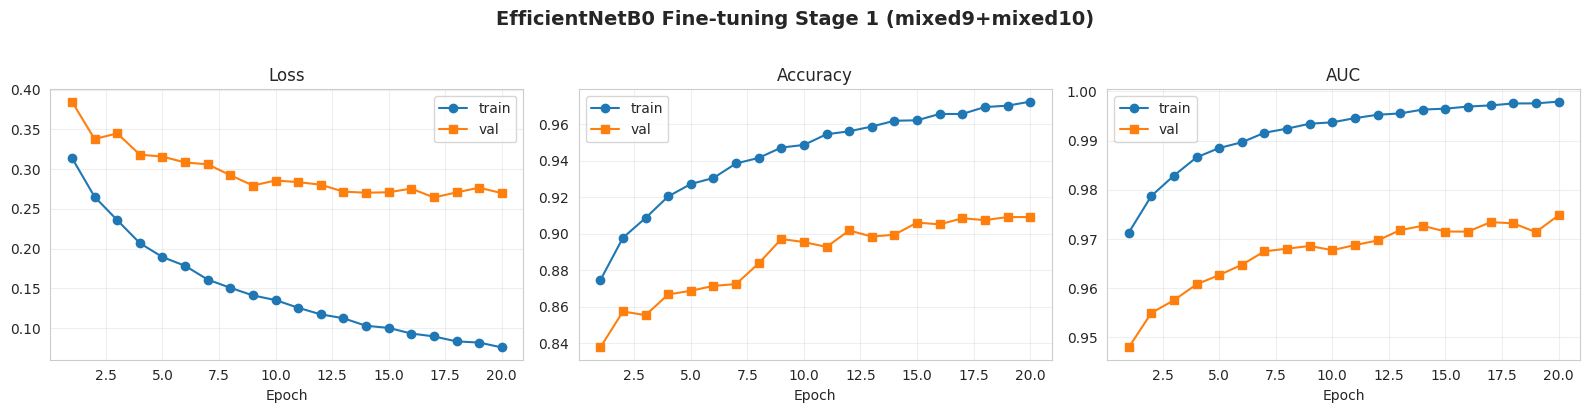

In [37]:
import matplotlib.pyplot as plt

def plot_history(hist, title="Training Curves"):
    h = hist.history
    epochs = range(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    axes[0].plot(epochs, h["loss"], label="train", marker='o')
    axes[0].plot(epochs, h["val_loss"], label="val", marker='s')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, h["accuracy"], label="train", marker='o')
    axes[1].plot(epochs, h["val_accuracy"], label="val", marker='s')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, h["auc"], label="train", marker='o')
    axes[2].plot(epochs, h["val_auc"], label="val", marker='s')
    axes[2].set_title("AUC")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_history(history_ft_stage1, "EfficientNetB0 Fine-tuning Stage 1 (mixed9+mixed10)")

📊 EVALUATION: FINE-TUNING STAGE 1 (mixed9+mixed10 unfrozen)
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 368ms/step

🔹 SLICE-LEVEL RESULTS (FT Stage 1)
Accuracy: 90.29%

              precision    recall  f1-score   support

         GLI     0.9332    0.9091    0.9210      1860
        METS     0.9508    0.9436    0.9472       656
       OTHER     0.7411    0.8229    0.7799       480

    accuracy                         0.9029      2996
   macro avg     0.8751    0.8919    0.8827      2996
weighted avg     0.9063    0.9029    0.9041      2996



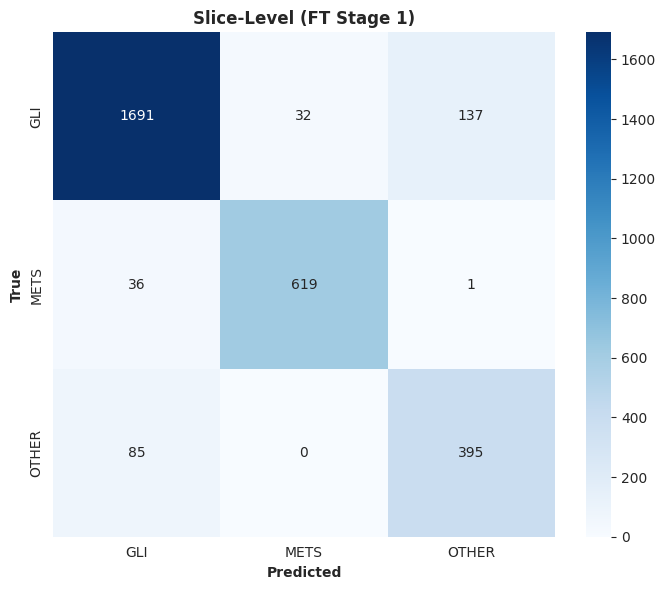

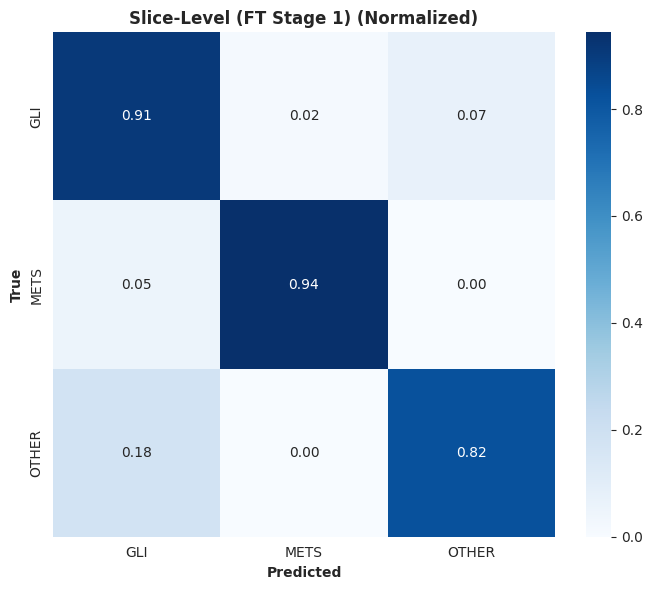


🔹 CASE-LEVEL RESULTS (FT Stage 1, Voting)
Accuracy: 95.33%

              precision    recall  f1-score   support

         GLI     0.9628    0.9731    0.9679       186
        METS     0.9744    0.9268    0.9500        41
       OTHER     0.8667    0.8667    0.8667        30

    accuracy                         0.9533       257
   macro avg     0.9346    0.9222    0.9282       257
weighted avg     0.9534    0.9533    0.9532       257



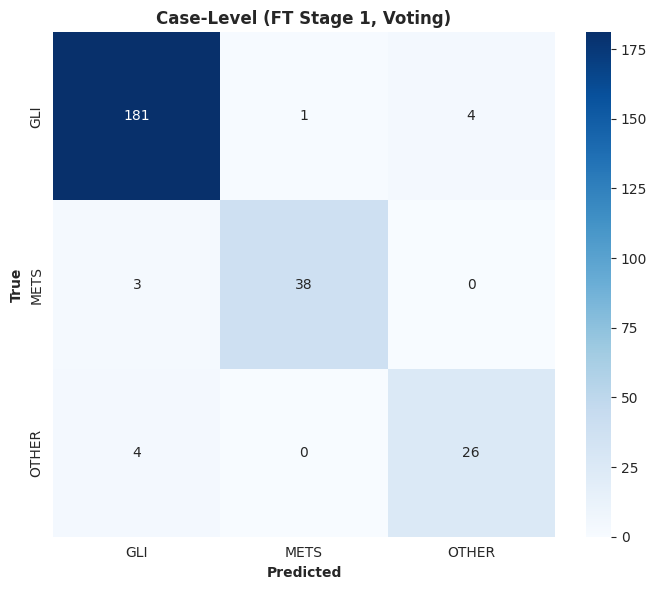

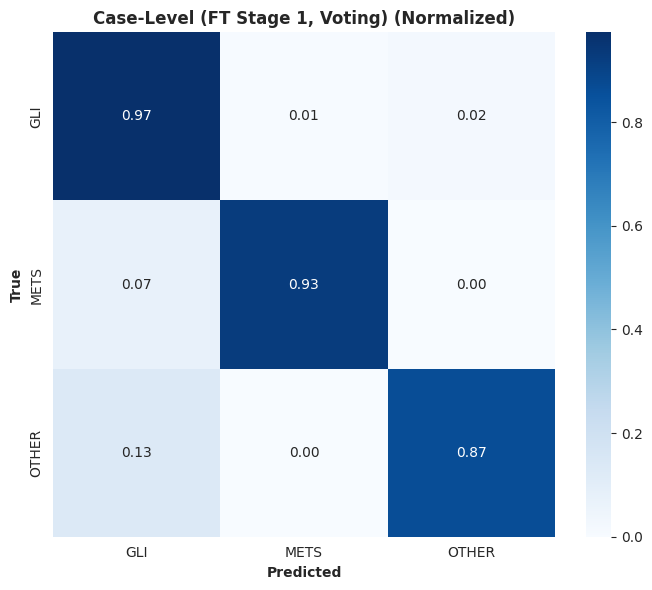

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

CLASS_NAMES = ["GLI", "METS", "OTHER"]

def plot_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
                cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(title + (" (Normalized)" if normalize else ""), fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")
    plt.tight_layout()
    plt.show()

def predict_with_metadata(model, gen):
    y_prob = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    case_keys = [ck for (ck, local_idx, lbl) in gen.samples]
    y_true = np.array([lbl for (ck, local_idx, lbl) in gen.samples], dtype=np.int32)
    return y_true, y_pred, y_prob, case_keys

def majority_vote(arr, n_classes=3):
    counts = np.bincount(arr, minlength=n_classes)
    top = counts.max()
    tied = np.where(counts == top)[0]
    return int(tied[0])

def case_level_vote(y_pred_slice, case_keys, clean_case_index):
    df = pd.DataFrame({"case_key": case_keys, "pred": y_pred_slice})
    y_pred_case = df.groupby("case_key")["pred"].apply(lambda s: majority_vote(s.values, n_classes=3))
    y_true_case = y_pred_case.index.to_series().apply(lambda ck: clean_case_index[ck]["class_label"])
    return y_true_case.values.astype(int), y_pred_case.values.astype(int)

print("=" * 70)
print("📊 EVALUATION: FINE-TUNING STAGE 1 (mixed9+mixed10 unfrozen)")
print("=" * 70)

# Slice-level
y_true_slice, y_pred_slice, _, case_keys = predict_with_metadata(model_efficient, test_gen)

print("\n" + "="*70)
print("🔹 SLICE-LEVEL RESULTS (FT Stage 1)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%\n")
print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_slice, y_pred_slice, "Slice-Level (FT Stage 1)", normalize=False)
plot_cm(y_true_slice, y_pred_slice, "Slice-Level (FT Stage 1)", normalize=True)

# Case-level
y_true_case, y_pred_case = case_level_vote(y_pred_slice, case_keys, clean_case_index)

print("\n" + "="*70)
print("🔹 CASE-LEVEL RESULTS (FT Stage 1, Voting)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_case, y_pred_case)*100:.2f}%\n")
print(classification_report(y_true_case, y_pred_case, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_case, y_pred_case, "Case-Level (FT Stage 1, Voting)", normalize=False)
plot_cm(y_true_case, y_pred_case, "Case-Level (FT Stage 1, Voting)", normalize=True)

# Stage 2 Fine Tuning

In [42]:
import tensorflow as tf
from tensorflow.keras import layers

# ------------------------------------------------------------
# 1) Extract EfficientNet base
# ------------------------------------------------------------
efficient_base = None
for layer in model_efficient.layers:
    if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
        efficient_base = layer
        break

if efficient_base is None:
    for layer in model_efficient.layers:
        if isinstance(layer, tf.keras.Model) and "efficient" in layer.name.lower():
            efficient_base = layer
            break

if efficient_base is None:
    raise ValueError("❌ Could not find EfficientNetB0 base model inside model_efficient")

print(f"\n✅ Found EfficientNet base: {efficient_base.name}")
print(f"   Total layers in base: {len(efficient_base.layers)}")


# ------------------------------------------------------------
# 2) Freeze all layers first
# ------------------------------------------------------------
for layer in efficient_base.layers:
    layer.trainable = False


# ------------------------------------------------------------
# 3) Unfreeze MORE layers for Stage 2
#    Default: 90 (good next step after 60), but capped safely.
# ------------------------------------------------------------
N_UNFREEZE_STAGE2 = 90
N_UNFREEZE_STAGE2 = min(N_UNFREEZE_STAGE2, len(efficient_base.layers))

for layer in efficient_base.layers[-N_UNFREEZE_STAGE2:]:
    # Keep BatchNorm frozen (recommended)
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

unfrozen = [l.name for l in efficient_base.layers if l.trainable]
print(f"\n✅ Stage 2: Unfrozen {len(unfrozen)} layers (last {N_UNFREEZE_STAGE2}, BN frozen)")
print(f"   Examples: {unfrozen[:5]} ... {unfrozen[-5:]}")


# ------------------------------------------------------------
# 4) Count trainable params
# ------------------------------------------------------------
trainable_count = sum([tf.size(w).numpy() for w in model_efficient.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in model_efficient.non_trainable_weights])

print(f"\n📊 Trainable params:     {trainable_count:,}")
print(f"📊 Non-trainable params: {non_trainable_count:,}")


# ------------------------------------------------------------
# 5) Recompile with LOWER LR for Stage 2
# ------------------------------------------------------------
multi_auc = tf.keras.metrics.AUC(multi_label=True, num_labels=NUM_CLASSES, name="auc")

model_efficient.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),  # smaller than stage 1
    loss="categorical_crossentropy",
    metrics=["accuracy", multi_auc]
)

print("✅ Model recompiled with LR=5e-6 for fine-tuning Stage 2")


# ------------------------------------------------------------
# 6) Callbacks + Fit
# ------------------------------------------------------------
EPOCHS_FT_STAGE2 = 20
ckpt_path_ft2 = "efficientnet_3class_finetune_stage2.keras"

callbacks_ft2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path_ft2,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print(f"🚀 Starting Fine-tuning Stage 2 (EfficientNetB0 last {N_UNFREEZE_STAGE2} layers)...")
print(f"   Epochs: {EPOCHS_FT_STAGE2}")
print(f"   Learning rate: 5e-6\n")

history_ft_stage2 = model_efficient.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT_STAGE2,
    callbacks=callbacks_ft2,
    verbose=1
)

print("\n✅ Fine-tuning Stage 2 complete!")


✅ Found EfficientNet base: efficientnetb0
   Total layers in base: 238

✅ Stage 2: Unfrozen 71 layers (last 90, BN frozen)
   Examples: ['block5c_expand_conv', 'block5c_expand_activation', 'block5c_dwconv', 'block5c_activation', 'block5c_se_squeeze'] ... ['block7a_se_expand', 'block7a_se_excite', 'block7a_project_conv', 'top_conv', 'top_activation']

📊 Trainable params:     3,664,266
📊 Non-trainable params: 714,027
✅ Model recompiled with LR=5e-6 for fine-tuning Stage 2
🚀 Starting Fine-tuning Stage 2 (EfficientNetB0 last 90 layers)...
   Epochs: 20
   Learning rate: 5e-6

Epoch 1/20


2026-02-26 13:57:32.340849: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-26 13:57:32.533167: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


338/813 ━━━━━━━━━━━━━━━━━━━━ 2:10 275ms/step - accuracy: 0.9761 - auc: 0.9983 - loss: 0.0699

2026-02-26 13:59:23.720115: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-26 13:59:23.907588: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.9750 - auc: 0.9982 - loss: 0.0715
Epoch 1: val_auc improved from -inf to 0.97335, saving model to efficientnet_3class_finetune_stage2.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 308s 337ms/step - accuracy: 0.9750 - auc: 0.9982 - loss: 0.0715 - val_accuracy: 0.9092 - val_auc: 0.9734 - val_loss: 0.2735 - learning_rate: 5.0000e-06
Epoch 2/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9779 - auc: 0.9986 - loss: 0.0638
Epoch 2: val_auc improved from 0.97335 to 0.97438, saving model to efficientnet_3class_finetune_stage2.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 189s 233ms/step - accuracy: 0.9779 - auc: 0.9986 - loss: 0.0638 - val_accuracy: 0.9156 - val_auc: 0.9744 - val_loss: 0.2717 - learning_rate: 5.0000e-06
Epoch 3/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9786 - auc: 0.9985 - loss: 0.0619
Epoch 3: val_auc did not improve from 0.97438
813/813 ━━━━━━━━━━━━━━━━━━━━ 180s 222ms/step - accuracy: 0.9786 - auc: 0.9985 - lo

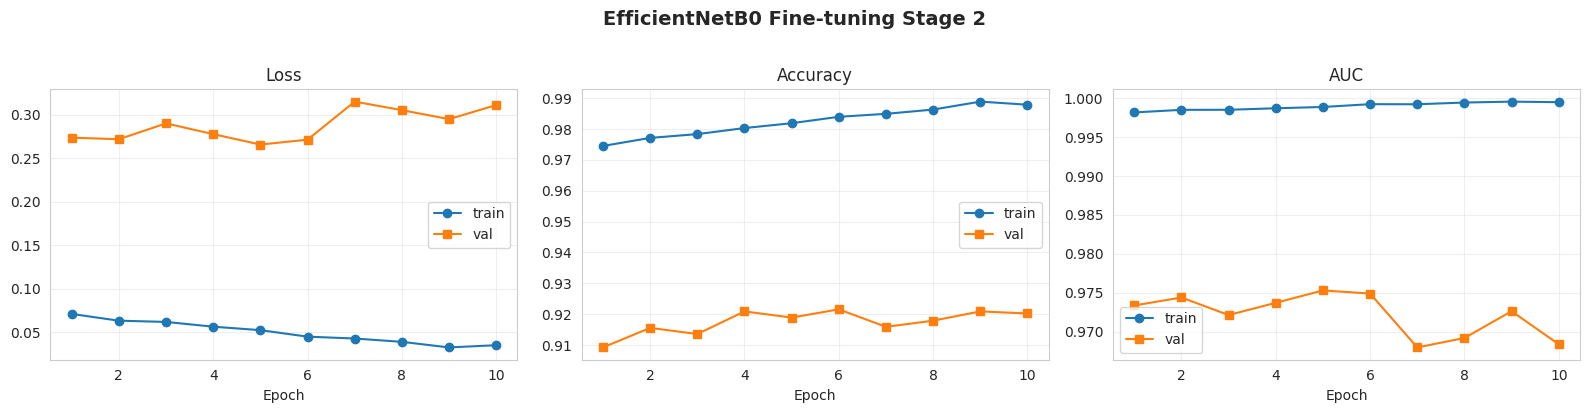

In [43]:
import matplotlib.pyplot as plt

def plot_history(hist, title="Training Curves"):
    h = hist.history
    epochs = range(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    axes[0].plot(epochs, h["loss"], label="train", marker='o')
    axes[0].plot(epochs, h["val_loss"], label="val", marker='s')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, h["accuracy"], label="train", marker='o')
    axes[1].plot(epochs, h["val_accuracy"], label="val", marker='s')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, h["auc"], label="train", marker='o')
    axes[2].plot(epochs, h["val_auc"], label="val", marker='s')
    axes[2].set_title("AUC")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_history(history_ft_stage2, "EfficientNetB0 Fine-tuning Stage 2")

📊 EVALUATION: FINE-TUNING STAGE 2
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 372ms/step

🔹 SLICE-LEVEL RESULTS (FT Stage 2)
Accuracy: 91.36%

              precision    recall  f1-score   support

         GLI     0.9270    0.9349    0.9309      1860
        METS     0.9553    0.9451    0.9502       656
       OTHER     0.8025    0.7875    0.7950       480

    accuracy                         0.9136      2996
   macro avg     0.8949    0.8892    0.8920      2996
weighted avg     0.9132    0.9136    0.9134      2996



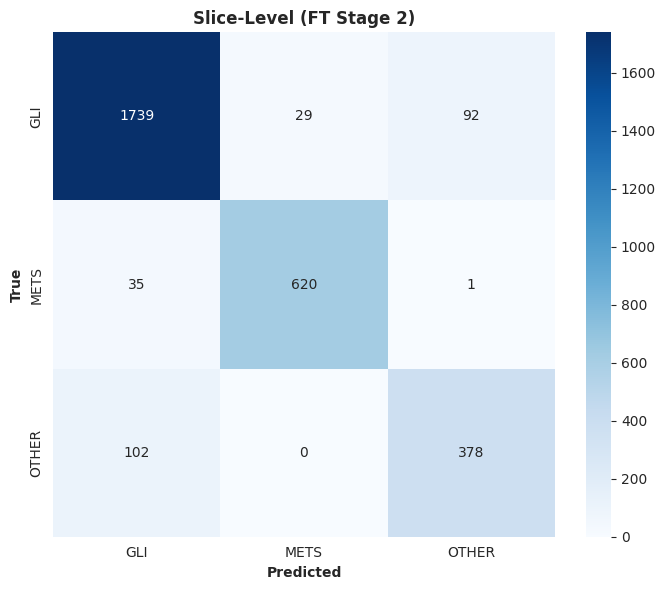

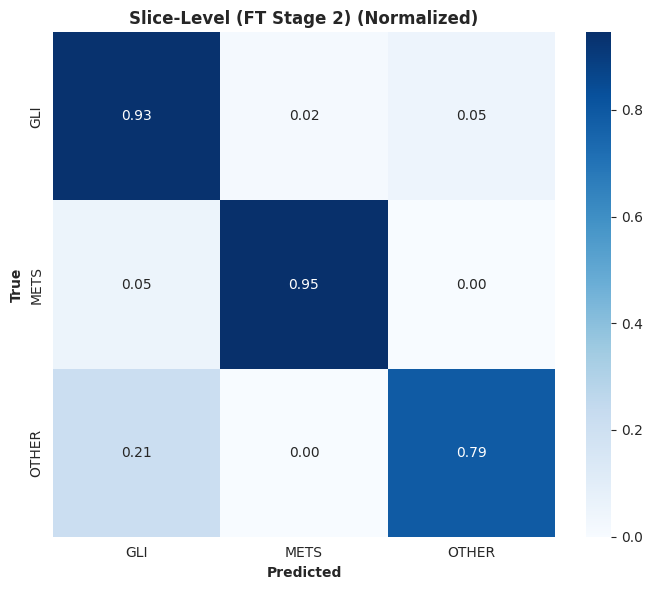


🔹 CASE-LEVEL RESULTS (FT Stage 2, Voting)
Accuracy: 95.33%

              precision    recall  f1-score   support

         GLI     0.9579    0.9785    0.9681       186
        METS     0.9744    0.9268    0.9500        41
       OTHER     0.8929    0.8333    0.8621        30

    accuracy                         0.9533       257
   macro avg     0.9417    0.9129    0.9267       257
weighted avg     0.9529    0.9533    0.9528       257



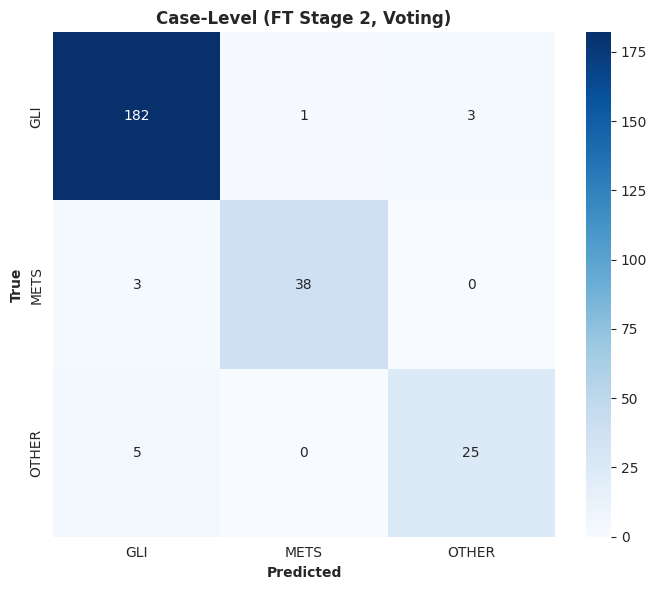

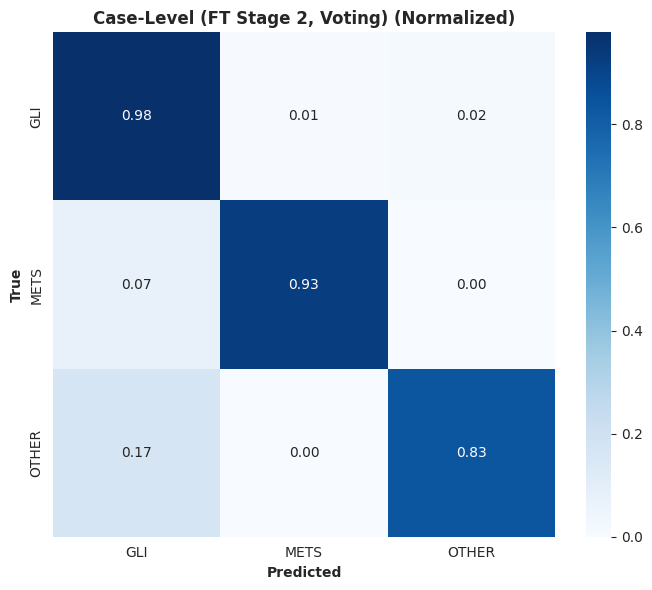

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

CLASS_NAMES = ["GLI", "METS", "OTHER"]

def plot_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
                cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(title + (" (Normalized)" if normalize else ""), fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")
    plt.tight_layout()
    plt.show()

def predict_with_metadata(model, gen):
    y_prob = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    case_keys = [ck for (ck, local_idx, lbl) in gen.samples]
    y_true = np.array([lbl for (ck, local_idx, lbl) in gen.samples], dtype=np.int32)
    return y_true, y_pred, y_prob, case_keys

def majority_vote(arr, n_classes=3):
    counts = np.bincount(arr, minlength=n_classes)
    top = counts.max()
    tied = np.where(counts == top)[0]
    return int(tied[0])

def case_level_vote(y_pred_slice, case_keys, clean_case_index):
    df = pd.DataFrame({"case_key": case_keys, "pred": y_pred_slice})
    y_pred_case = df.groupby("case_key")["pred"].apply(lambda s: majority_vote(s.values, n_classes=3))
    y_true_case = y_pred_case.index.to_series().apply(lambda ck: clean_case_index[ck]["class_label"])
    return y_true_case.values.astype(int), y_pred_case.values.astype(int)

print("=" * 70)
print("📊 EVALUATION: FINE-TUNING STAGE 2")
print("=" * 70)

# Slice-level
y_true_slice, y_pred_slice, _, case_keys = predict_with_metadata(model_efficient, test_gen)

print("\n" + "="*70)
print("🔹 SLICE-LEVEL RESULTS (FT Stage 2)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%\n")
print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_slice, y_pred_slice, "Slice-Level (FT Stage 2)", normalize=False)
plot_cm(y_true_slice, y_pred_slice, "Slice-Level (FT Stage 2)", normalize=True)

# Case-level
y_true_case, y_pred_case = case_level_vote(y_pred_slice, case_keys, clean_case_index)

print("\n" + "="*70)
print("🔹 CASE-LEVEL RESULTS (FT Stage 2, Voting)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_case, y_pred_case)*100:.2f}%\n")
print(classification_report(y_true_case, y_pred_case, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_case, y_pred_case, "Case-Level (FT Stage 2, Voting)", normalize=False)
plot_cm(y_true_case, y_pred_case, "Case-Level (FT Stage 2, Voting)", normalize=True)

#  Summary (Fill it manually)

In [ ]:
import pandas as pd

# Manually fill in your results from Stage 0, Stage 1, and Stage 2
efficient_results = pd.DataFrame({
    "Stage": ["Stage 0 (Frozen)", "FT Stage 1 (mixed9+10)", "FT Stage 2 (mixed7+8+9+10)"],
    "Slice Accuracy (%)": [0.0, 0.0, 0.0],  # Fill in your actual values
    "Case Accuracy (%)": [0.0, 0.0, 0.0],   # Fill in your actual values
    "GLI F1": [0.0, 0.0, 0.0],
    "METS F1": [0.0, 0.0, 0.0],
    "OTHER F1": [0.0, 0.0, 0.0]
})

print("\n" + "="*70)
print("📊 EfficientNetB0 TRAINING SUMMARY")
print("="*70)
print(efficient_results.to_string(index=False))